<div style="border:solid Purple 2px; padding: 40px">
<b>Ирина, привет!</b>

Предлагаю следующие правила при обсуждении твоего проекта.

Ты увидишь мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:


<div class="alert alert-success">
<h3> Комментарий Александра 😊<a class="tocSkip"> </h3>
    
Такими комментариями я буду помечать отличные моменты в твоем проекте😉
</div>
    
<div class="alert alert-warning">
<h3> Комментарий Александра 🤓<a class="tocSkip"> </h3>
        
В таких комментариях я постараюсь порекомендовать, более элегантное или легкое решение, некоторые хитрости и фишки, позволяющие улучшить твой проект. Части проекта, помеченные такими комментариями, можно не исправлять, но рекомендую обратить на них внимание.</div>

<div class="alert alert-block alert-danger">
<h3> Комментарий Александра 🤔<a class="tocSkip"></h3>
    
В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Если ты видишь такой комментарий, значит здесть есть недочет, который следует исправить.
</div>

Ты также можешь реагировать на мои комментарии своими, выделяя их цветами и наиболее понравившимся тебе способом оформления, но явно  отличающимся от моих комментариев. Это нужно, чтобы не создавалась путаница🙃 
    
<div class="alert alert-info"> <b>Комментарий Ирины:</b> Например, вот так.</div>

Пожалуйста, не удаляй и не перемещай мои комментарии, это будет полезнно в случае повторной проверки проекта. </div>

# Загрузка датасета и первичный осмотр данных

<div class="alert alert-block alert-danger">
<h2> Комментарий Александра 🤔<a class="tocSkip"></h2>

Ирина, куда делось название проекта и вся описательная часть? Проект должен быть цельным, включая такие обязательные компоненты как описание проблемы, поставновка задачи, порядок выполнения работы и прочяя информация из блокнота churn_predict.ipynb.

Это поможет любому человеку, открывшему твой отчет, понять контекст, что происходит и с какой целью.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Описание добавлено.</div>

<div class="alert alert-success">
<h3> Комментарий Александра (2) 😊<a class="tocSkip"> </h3>
    
OK
</div>

In [1]:
import pandas as pd
import numpy as np

#подгпрузка данных
df = pd.read_csv('Customer-Churn.csv')

#просмотр первых пяти строк, чтобы убедиться, что мы все правильно подгрузили 
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,NaN,12547842,Sokolov,709.0,France,Female,36,4,174056.41,1,1,1.0,40449.79,0,0.0,2.0,SILVER,752
1,6294.0,15783083,Shubin,534.0,France,Male,27,9,0.00,2,1,0.0,161344.13,0,0.0,2.0,PLATINUM,925
2,6919.0,15721116,Napolitano,597.0,Spain,Male,24,0,108058.07,2,1,1.0,187826.11,0,0.0,3.0,PLATINUM,676
3,NaN,4819046,Anderson,659.0,Germany,Female,26,9,84870.44,1,1,1.0,NaN,0,0.0,4.0,DIAMOND,727
4,3951.0,15602841,Lockett,794.0,Spain,Female,28,5,0.00,2,0,1.0,86699.98,0,0.0,3.0,DIAMOND,734


In [2]:
#Узнаем размер датасета
df.shape

(20000, 18)

Мы имеем датасет, состоящий из 18 признаков и 2000 наблюдений

In [3]:
#рассмотрим общую информацию о типах данных и наличии пропусков 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  float64
 1   CustomerId          20000 non-null  int64  
 2   Surname             20000 non-null  object 
 3   CreditScore         16874 non-null  float64
 4   Geography           20000 non-null  object 
 5   Gender              20000 non-null  object 
 6   Age                 20000 non-null  int64  
 7   Tenure              20000 non-null  int64  
 8   Balance             20000 non-null  float64
 9   NumOfProducts       20000 non-null  int64  
 10  HasCrCard           20000 non-null  int64  
 11  IsActiveMember      19230 non-null  float64
 12  EstimatedSalary     17541 non-null  float64
 13  Exited              20000 non-null  int64  
 14  Complain            19230 non-null  float64
 15  Satisfaction Score  19230 non-null  float64
 16  Card

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Хорошее начало! Датасет загружен.
</div>

# Чистка и предобработка данных

можно заметить, что типы данных почти у всех признаков впорядке, кроме признака complain - наличие жалобы у клиента(бинарные переменные 1 и 0), их тип должен быть int
В рассматриваемом датасете немаленькое количество пропусков, простое удаление строк с пропущенными значениями критично
такие признаки как RowNumber, CustomerID и Surname являются неинформативными, их можно удалить из датасета,  
остальные же признаки с пропущенными значениями удалять нельзя, например, признак CreditScore  имеет 3126 пропуксков, что составляет 15,6%, а признак EstimatedSalary имеет 2459 пропусков(12,3%), это слишком большие числа, при их удалении можно потерять важную информацию

In [4]:
#удаление неинформативных признаков:
df = df.drop('RowNumber', axis = 1)
df = df.drop('CustomerId', axis = 1)
df = df.drop('Surname', axis = 1)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,709.0,France,Female,36,4,174056.41,1,1,1.0,40449.79,0,0.0,2.0,SILVER,752
1,534.0,France,Male,27,9,0.00,2,1,0.0,161344.13,0,0.0,2.0,PLATINUM,925
2,597.0,Spain,Male,24,0,108058.07,2,1,1.0,187826.11,0,0.0,3.0,PLATINUM,676
3,659.0,Germany,Female,26,9,84870.44,1,1,1.0,NaN,0,0.0,4.0,DIAMOND,727
4,794.0,Spain,Female,28,5,0.00,2,0,1.0,86699.98,0,0.0,3.0,DIAMOND,734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,788.0,France,Male,34,1,64191.06,2,1,0.0,37217.73,1,0.0,3.0,DIAMOND,222
19996,576.0,France,Male,42,4,137429.76,2,0,0.0,137330.80,0,0.0,2.0,GOLD,740
19997,711.0,France,Female,29,3,130181.47,2,1,0.0,31811.44,0,0.0,5.0,SILVER,719
19998,647.0,Spain,Male,32,9,80958.36,1,1,1.0,128590.73,0,0.0,4.0,GOLD,540


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

1. Можно удаление столбцов выполнить одной строкой:  
    ```python
    #удаление неинформативных признаков:
    df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True, errors='ignore')
    ```  
1. Рекомендую делать карту пропусков:
    ```python
    sns.heatmap(df.isna().T, cmap='Blues_r', annot=False, cbar=False)
    plt.title('Карта пропусков');
    ```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Удаление столбцов исправлено, карта пропусков создана).</div>

<div class="alert alert-success">
<h3> Комментарий Александра (2) 😊<a class="tocSkip"> </h3>
    
OK. Теперь мы видим, что пропуски совпадают в `IsActiveMember`, `Complain` и `Satisfaction Score`.
</div>

Проверим наличие полных дубликатов в датасете

In [5]:
df.duplicated().sum()

np.int64(0)

Дубликатов в датасете нет

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Первое знакомство с данными. Все хорошо.
</div>

## Начнем с первого признака CreditScore(кредитный рейтинг), имеющего самое большое колмичество пропусков

Тип данных float из-за пропусков

рассмотрим статистические показатели для данного признака

In [6]:
df.CreditScore.describe()

count    16874.000000
mean       649.436115
std         96.687706
min        350.000000
25%        582.000000
50%        651.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

Медиана - 651 --> половина клиентов имеет рейтинг выше этого значения, основываясь на описатнельной статистике, данные без аномалий, среднее квадратическое отклонение не сильно большое, данные признака распределены от 350 до 850

Заменим пропуски признака на медиану = 651


убедимся, что нашли медиану не по пустым значениям

In [7]:
credit_median = df['CreditScore'].median()
credit_median

np.float64(651.0)

медиана совпала с той, что мы определили ранее, заменим пропуски на медиану

In [8]:
#создадим флаг
df['CreditScore_was_missing'] = df['CreditScore'].isnull().astype(int)
df['CreditScore'] = df['CreditScore'].fillna(credit_median)

проверим отсутствие пропусков

In [9]:
df.CreditScore.isnull().sum()

np.int64(0)

Отлично, пропуски признака CreditScore заполнены. 

Рассмотрим аномалии, для этого построим гистограмму

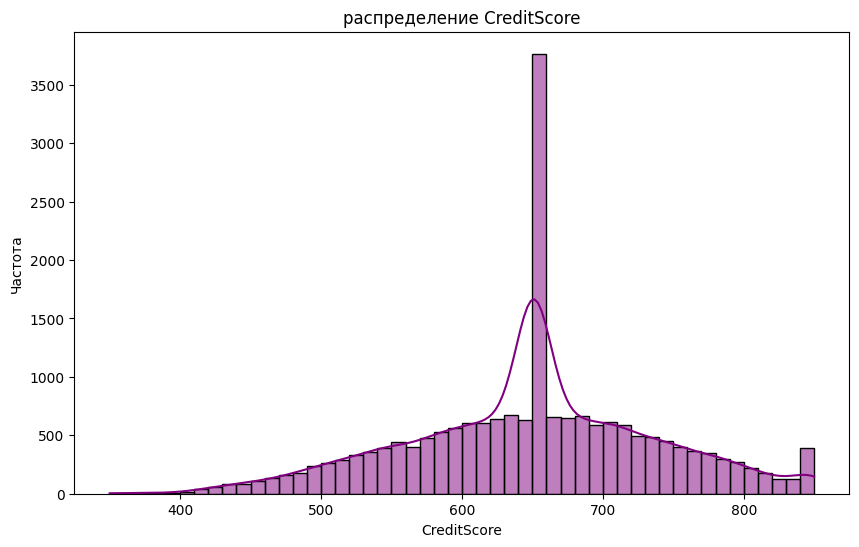

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

#гистограмма
sns.histplot(df['CreditScore'], bins = 50, kde = True, color = 'purple', edgecolor = 'black')
plt.title('распределение CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Частота')
plt.show()

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>
        
1. Все импорты, всегда помещаются в начале файла, если придерживаться правил PEP8
(https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html#section-8).  
А их желательно придерживаться. Это позволяет пользователю, читающему отчет, сразу видеть какие библиотеки необходимо установить.

1. Команду `plt.show()` можно не писать, если стоящую перед ней команду завершить знаком `;` (точка с запятой):

```python
#гистограмма
sns.histplot(df['CreditScore'], bins = 50, kde = True, color = 'purple', edgecolor = 'black')
plt.title('распределение CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Частота');
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Импорты перенесла в начало фвайла, про plt.show() учту, не знала).</div>

<div class="alert alert-success">
<h3> Комментарий Александра (2) 😊<a class="tocSkip"> </h3>
    
Хорошо, теперь сразу понятно, какие библиотеки будем использовать в дальнейшем.
</div>

<div class="alert alert-warning">
<h3> Комментарий Александра (2) 🤓<a class="tocSkip"> </h3>
    
Длинные импорты можно делать в несколько строк, вот так:
```python
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    precision_recall_curve, brier_score_loss
)
```
</div>

распределение нормальное, но мы имеем экстремальный пик на значении 651, это нормально так как на моменте обработки пропусков все NaN заменили медианой, для модели это будет некритично так как у нас есть флаг, он поможет модели понять что это не настоящий рейтинг, а восстановленное значение. 

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Гут, избавились от пропусков в CreditScore.
</div>

## Рассмотрим следующий признак, имеющий пропуски, EstimatedSalary - прогнозируемый доход 

2459 пропусков. Проверим данные

In [11]:
df.EstimatedSalary.describe()

count    1.754100e+04
mean     1.412469e+05
std      3.779394e+05
min     -1.993075e+05
25%      4.955338e+04
50%      1.013711e+05
75%      1.520528e+05
max      5.123361e+06
Name: EstimatedSalary, dtype: float64

В данных присутствуют отрицательные значения, посмотрим сколько их

In [12]:
#Сколько отрицательных
anomalous_Salary = df[df['EstimatedSalary'] < 0]
print(f'количество отрицательных значений: {len(anomalous_Salary)}')

количество отрицательных значений: 81


Медиана у данного признака 101371, заполним ею пропуски и создадим флаг пропуска

In [13]:
#создадим флаг
df.EstimatedSalary_was_missing = df.EstimatedSalary.isnull().astype(int)

#находим медиану
median_salary = df.EstimatedSalary.median()
print(f'Mедиана EstimatedSalary: {median_salary:,.0f}')

#заполним пропуски медианой
df.EstimatedSalary = df.EstimatedSalary.fillna(median_salary)
#проверим результат
print('Пропусков в EstimatedSalary после обработки:', df.EstimatedSalary.isnull().sum())
print('Количество клиентов с пропущенным доходом:', df.EstimatedSalary_was_missing.sum())

Mедиана EstimatedSalary: 101,371
Пропусков в EstimatedSalary после обработки: 0
Количество клиентов с пропущенным доходом: 2459


/tmp/ipykernel_412451/470407510.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.EstimatedSalary_was_missing = df.EstimatedSalary.isnull().astype(int)


<div class="alert alert-block alert-danger">
<h2> Комментарий Александра 🤔<a class="tocSkip"></h2>

Получили предупреждение от pandas, что он не позволяет создавать новые столбцы с помощью имени атрибута. К существующим столбцам такое обращение допустимо, а при создании нового столбца, необходимо указывать его название в квадратных скобках:

```python
#создадим флаг
df['EstimatedSalary_was_missing'] = df.EstimatedSalary.isnull().astype(int)
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Предупреждение исправлено.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>
    
ОК
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>
        
В команде `print` можно использовать многострочный вывод:

```python
print(f'''
Mедиана EstimatedSalary: {median_salary:,.0f}
Пропусков в EstimatedSalary после обработки: {df.EstimatedSalary.isnull().sum()}
Количество клиентов с пропущенным доходом: {df.EstimatedSalary_was_missing.sum()}
''')
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Про многострочный вывод знаю, но мне легче читать код, когда разные данные разделены на разные принты, пожалуй, оставлю так как было).</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>
    
ОК
</div>

Проверим выбросы в EstimatedSalary

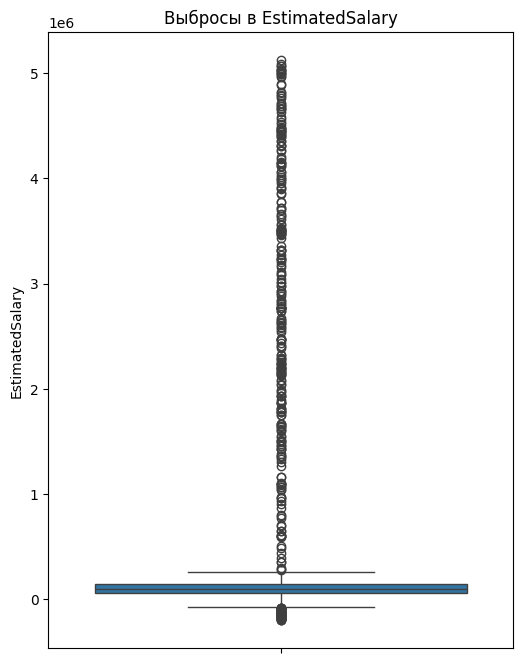

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (6,8))
sns.boxplot(y = df['EstimatedSalary'])
plt.title('Выбросы в EstimatedSalary')
plt.show()

Выбросы в признакаках доходов полне реальны, отрицательные значения тоже могут быть объяснимы, учитывая что признак называется "прогнозируемый доход", можно предположить, что речь идет об акциях, купленных в банке(признак "баланс") и прогнозируемый доход это процент от акций, акции могли упасть и тогда отрицательные значения вполне реальны. Для решения этой проблемы применим биннинг и WOE  кодипрование

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Заполнили пропуски в EstimatedSalary. Идем дальше.
</div>

## Переходим к обработке нового признака - IsActiveMember - признак активного клиента

у данного признака, как мы выяснили ранее, 770 пропусков, что составляет 3.85% от количества наблюдений

In [15]:
print('Тип данных: ', df.IsActiveMember.dtype)
print('Колиество пропусков: ', df.IsActiveMember.isnull().sum())
print('Уникальные значения: ', df.IsActiveMember.unique())

Тип данных:  float64
Колиество пропусков:  770
Уникальные значения:  [ 1.  0. nan]


Тип данных float - не подходящий для бинарной переменной, мы сможем изменить его на int() после обработки пропусков.

Варианты наличия пропущенных значений: 

    *ошибка выгрузки
    
    *клиент новый и еще не накоплено его поведение
    
    *клиент не совершал операций - система не определила его активность 

In [16]:
#создадим флаг
df.IsActiveMissing = df.IsActiveMember.isnull().astype(int)

/tmp/ipykernel_412451/1771556661.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.IsActiveMissing = df.IsActiveMember.isnull().astype(int)


<div class="alert alert-block alert-danger">
<h2> Комментарий Александра 🤔<a class="tocSkip"></h2>

Необходимо исправить.

```python
#создадим флаг
df['IsActiveMissing'] = df.IsActiveMember.isnull().astype(int)
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> исправлено.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>
    
ОК
</div>

Заполним пропуски, для этого мы хотим понять клиенты, у которых нет данных об активности чаще уходят или нет?

In [17]:
df_temp = df[['IsActiveMember', 'Exited']].copy() #создадим вуременную таблицу, чтобы не трогать оригинал
df_temp['is_missing'] = df_temp['IsActiveMember'].isnull() #новый столбец is_missing, он равен True, если IsActiveMember - пропук, и False - если есть значение

churn_by_missing = df_temp.groupby('is_missing')['Exited'].agg(  #группируем клиентов на две группы: 1)is_missing = True(был пропуск) и 2) is_missing = False(данные были)
    count = 'size',    #и считаем для каждой count - сколько таких клиентов и churn_rate - среднее по exited -> доля ушедших
    churn_rate = 'mean'
).round(3)

print(churn_by_missing)

            count  churn_rate
is_missing                   
False       19230       0.204
True          770       0.144


Получается, что у клиентов, с данными об активности, отток 20.4, а у клиентов с отсутствием данных, отток 14.4%

Вывод: клиенты с пропуском в IsActiveMember уходят реже, чем те, у кого данные есть

Заполним пропуски модой - наиболее частым значением(0 или 1), потому что:

1) Сам пропуск не означает неактивность: анализ показал, что клиенты с пропуском уходят реже 

2) Это может быть новый или еще неоценимый клиент, и нет оснований считать его неактивным

3) Чтобы не вносить искажений, мы сохранили типичное поведение большинства

почему выбрана именно мода?
Мода минимизирует влияние на распределение и подходит когда нет ясной логики, как заполнить

In [18]:
mode_val = df['IsActiveMember'].mode()[0]
df['IsActiveMember'] = df['IsActiveMember'].fillna(mode_val)
df['IsActiveMember'] = df['IsActiveMember'].astype(int)

In [19]:
#проверим наличие пропусков и тип IsActiveMember
print('Тип данных признака IsActiveMember:', df.IsActiveMember.dtypes)
print('Количество пропусков в признаке IsActiveMember:', df.IsActiveMember.isna().sum())

Тип данных признака IsActiveMember: int64
Количество пропусков в признаке IsActiveMember: 0


<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Хорошо, что подробно описываешь процесс и поясняешь, как и почему заполняются пропуски.
</div>

## Переходим к обработке следующего признака: Age

In [20]:
#Проверим данные
print('Тип данных: ', df.Age.dtype)
print('Колиество пропусков: ', df.Age.isnull().sum())
print('Описание:')
df.Age.describe()

Тип данных:  int64
Колиество пропусков:  0
Описание:


count    20000.000000
mean      1110.932450
std       4489.620963
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max      33603.000000
Name: Age, dtype: float64

По описательной статистике явно видно, что в признаке Age есть аномалии, проверим сколько таких значений

In [21]:
#Сколько клиентов старше 100 лет?
anomalous_age = df[df['Age'] > 100]
print(f'количество клиентов старше 100 лет: {len(anomalous_age)}')

количество клиентов старше 100 лет: 1100


In [22]:
anomalous = df[df['Age'] > 100]['Age'].sort_values().value_counts().head(20)
anomalous

Age
16801    126
17897     94
17166     88
17532     83
18627     78
18262     69
18993     68
19358     64
19723     55
20819     52
20454     43
20088     40
21184     32
21549     28
21915     24
22280     20
22645     18
23010     17
23741     16
24106     12
Name: count, dtype: int64

гипотеза: аномальные значения в Age - данные, случайно занесенные в Age из признаков balance или CustomerID
проверим совпадение столбца Age c другими balance и CustomerID

In [23]:
balance_values = df['Balance'].isin([16801,17897,17166,17532,18627,18262,18993,19358,19723,20819,20454,20088,21184,21549,21915,22280,22645,23010,23741,24106])
print('Совпадение с Balance:', balance_values.sum())

if 'CustomerID' in df.columns:
    id_values = df['CustomerID'].isin(16801,17897,17166)
    print(id_values.sum())

Совпадение с Balance: 0


На основании проверки можно сделать вывод, что данные признака age испорчены, аномальные значения не похожи на год рождения, не походы на формат даты дд.мм.гг, совпапдений с признаками balance или CustomerID не выявлено

На данный момент удалять признак Age не вижу смысла, решение о возможном удалении будет зависеть от дальнейшего анализа. На данный момент создам флаг аномалии и значения признака Age, большие 100, заменю на медиану

In [24]:
#флаг
df['Age_was_anomalous'] = (df['Age'] > 100).astype(int)

#заменим аномалии на NaN и заполним медианой
df['Age'] = df['Age'].where(df['Age'] <= 100, np.nan)
df['Age'] = df['Age'].fillna(df['Age'].median())

In [25]:
df.Age.describe()

count    20000.000000
mean        37.966750
std          9.582204
min         18.000000
25%         32.000000
50%         37.000000
75%         42.000000
max         92.000000
Name: Age, dtype: float64

теперь данные признака Age выглядят осмысленно

построим гистограмму распределения

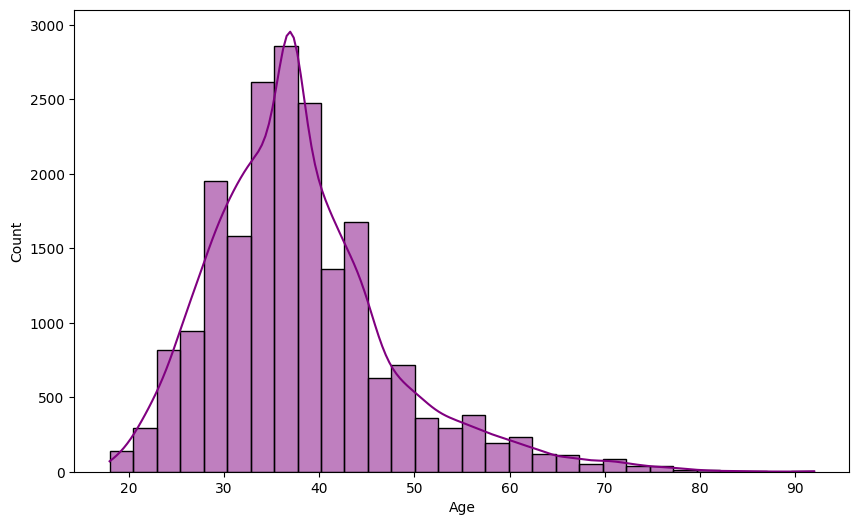

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins = 30,kde = True, color = 'purple')

plt.show()

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Принято.
</div>

## Рассмотрим признаки complain(наличие жалобы) и Satisfaction Score(оценка решения)

узнаем сколько пропусков в Complain

In [27]:
print('всего пропусков',df['Complain'].isnull().sum())
print('процент пропусков от всех данных:',df['Complain'].isnull().mean()*100)

всего пропусков 770
процент пропусков от всех данных: 3.85


Проведем анализ, который покажет:

    Сколько клиентов не жаловались, но есть оценка(подозрительно)

    Сколько жаловались и есть оценка(логично)

    Сколько жаловались, но оценки нет(возможно, не оценили)

    Сколько не жаловались и оценки нет(нейтральные)

На основании этого анализа сделаем вывод что делать с пропусками

In [28]:
#условие
conditions = {
    'не жаловались, но оценка есть':
    (df['Complain'] == 0) & (df['Satisfaction Score']).notna(),

    'жаловались и оценили':
    (df['Complain'] == 1) & (df['Satisfaction Score']).notna(),

    'жаловались и не оценили':
     (df['Complain'] == 1) & (df['Satisfaction Score']).isna(),

    'не жаловались и не оценили':
    (df['Complain'] == 0) & (df['Satisfaction Score']).isna(),
}

#считаем количество и долю:
results = {}
for label, mask in conditions.items():
    count = mask.sum()
    percent = (count / len(df)) * 100
    results[label] = {'Count': count, 'Percent (%)': round(percent,2)}

#выводим таблицу
summary_df = pd.DataFrame(results).T
print('Распределение по комбинациям Complain и Satisfaction Score')
print(summary_df)

Распределение по комбинациям Complain и Satisfaction Score
                                 Count  Percent (%)
не жаловались, но оценка есть  15142.0        75.71
жаловались и оценили            4088.0        20.44
жаловались и не оценили            0.0         0.00
не жаловались и не оценили         0.0         0.00


такие данные указывают либо на ошибку выгрузки данных, либо на неправильное трактование признаков в тз, слишком большое количество клиентов не имели жалобы, но при этом ее решение оценили

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>
    
Интересная статистика.
</div>

### Обработка пропусков Complain

Варианты заполнения:

1. Заменить на 0 (не жаловался) - рискуем стереть реальные жалобы, если система их не зафиксировла 

2. Заменить на 1 - искусственно повысим отток, можем исказить модель

3. Создать три флага - сохраним неопределенность

заменять пропуски на 0 и 1 без основания не стоит 

In [29]:
#создадим три флага и в будущем подадим их в модель вместо Complain
df['Complain_Yes'] = (df['Complain'] == 1).astype(int) #была жалоба -> 1, не было жалобы -> 0
df['Complain_No'] = (df['Complain'] == 0).astype(int) #не было жалобы -> 1, была жалоба или неизвестно -> 0
df['Complain_Missing'] = df['Complain'].isna().astype(int) # были пропуски -> 1, данные были -> 0

По итогу, флаг Complain_Yes - клиент жаловался и это зафиксировано

    флаг Complain_No - клиент НЕ жаловался и это зафиксировано(1 - не жаловался)
    
    флаг Сomplain_Missing - был ли пропуск (1 - был NaN, 0 - были данные (либо 0, либо 1))

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Обработали пропуски в Complain. Идем дальше.
</div>

### обработка пропусков Satisfaction Score

In [30]:
df['Satisfaction Score'].isna().sum()

np.int64(770)

убедимся что оценка только у жаловавшихся

In [31]:
#если Complain != 1, то оценки быть не должно
df.loc[df['Complain'] != 1, 'Satisfaction Score'] = np.nan

#среди тех, кто жаловался, заполним пропуски
#вычисляем среднюю оценку среди жаловавшихся
mean_score = df[df['Complain'] == 1]['Satisfaction Score'].mean()

#заполняем пропуски только у них
df.loc[df['Complain'] == 1, 'Satisfaction Score'] = \
    df.loc[df['Complain'] == 1, 'Satisfaction Score'].fillna(mean_score)

In [32]:
df['Satisfaction Score'].isna().sum()

np.int64(15912)

Satisfaction Score теперь не пустой ТОЛЬКО у тех, кто жаловался

создадим два флага: 

    satisfaction_provided = 1 - оценка была предоставлена, 

    satisfaction_provided = 0 - оценка не была предоставлена

In [33]:
df['Satisfaction_Fill'] = df['Satisfaction Score'].fillna(0)
df['Satisfaction_Provided'] = df['Satisfaction Score'].notna().astype(int)

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Оставляя оценки только при наличии жалобы, мы искажаем исходные данные.

Если оценки есть, а жалоб нет, то возможно, есть неточность в описании данных. Можно предположить, что оценка отражает не только реакцию на жалобу, а является результатом стандартного опроса при любом обращении в банк.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Я оставила оценки только при наличии жалобы, чтобы сфокусироваться на реакции клиента на жалобу - ключевой сигнал  для оттока, при этом создала флаг Satisfaction_Provided, который показывает была ли предоставлена оценка.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>
    
ОК, ты аналитик, твои правила.

Но при этом важно, суметь свои действия объяснить и обосновать. :)
</div>

### Balance

Проверим пропуски и тип

In [34]:
print('тип данных: ', df['Balance'].dtype)
print('количество пропусков: ', df['Balance'].isnull().sum())

тип данных:  float64
количество пропусков:  0


тип данных float - в сумме учитываются копейки, его менять не нужно. Пропусков нет

In [35]:
df['Balance'].describe()

count     20000.000000
mean      77543.121707
std       59293.459743
min           0.000000
25%        8457.702500
50%       85150.295000
75%      123684.380000
max      250898.090000
Name: Balance, dtype: float64

Минимальное значение нулевое, значит в датасете есть клиенты с нулевым балансом, что является нормой. Максимальное значения тоже приемлемо. Стандартное отклонение высокое, значит разброс большой

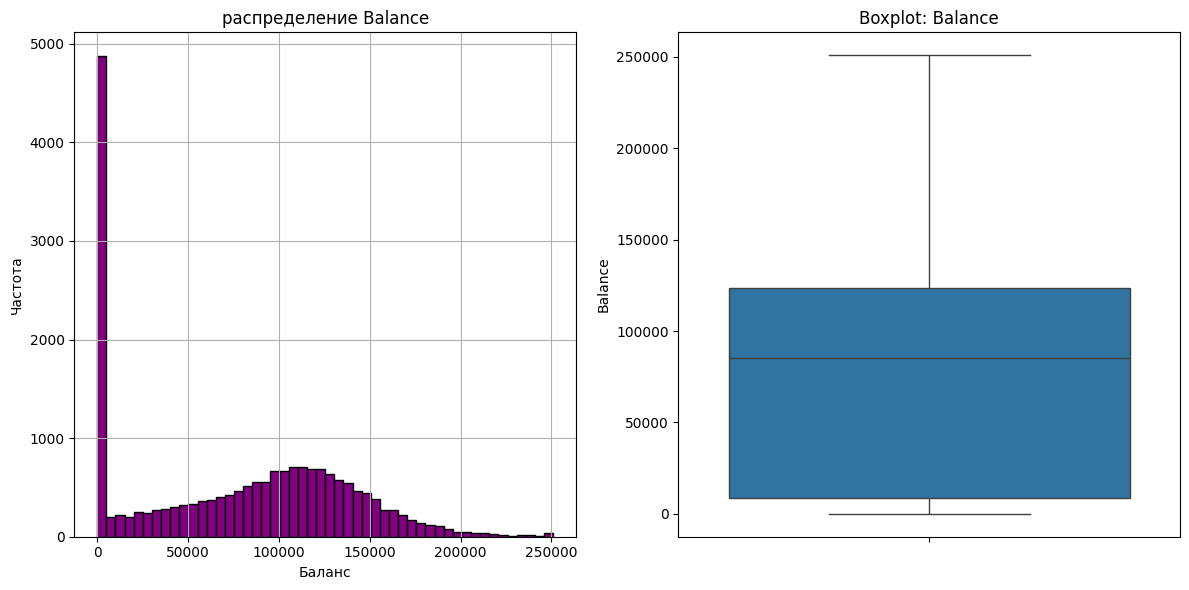

In [36]:
#Проверим на выбросы с помощью визуализации
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12,6))

#гистограмма
plt.subplot(1,2,1)
df['Balance'].hist(bins = 50, color = 'purple', edgecolor = 'black')
plt.title('распределение Balance')
plt.xlabel('Баланс')
plt.ylabel('Частота')

#boxplot
plt.subplot(1,2,2)
sns.boxplot(y = df['Balance'])
plt.title('Boxplot: Balance')

plt.tight_layout()
plt.show()

На гистограмме можно наблюдать пик клиентов с нулевым балансом - вполне логично, у многих клиентов открыт счет, но без средств на нем. Основная часть клиентов хранит на счету от 10000 до 130000, это 
можно заметить как на гистограмме, так и на ящике с усами, 25-й процентиль примерно 10000, 75-й процентиль примерно 130000

На гистограмме положительно скошенное распределение(слева от медианы высота столбиков чуть выше, чем справа от медианы), большинство клиентов имеют относительно небольшие балансы - низкий 
или средний уровень сбережений

Отрицательный баланс не наболюдается, экстремально высокого баланса тоже нет

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Все верно.
</div>

## NumOfProducts - количество продуктов банка у клиента

In [37]:
print('тип данных:', df['NumOfProducts'].dtype)
print('количество пропусков: ', df['NumOfProducts'].isna().sum())

тип данных: int64
количество пропусков:  0


Пропусков нет, тип данных корректный.

## HasCrCard - наличие кредитной карты

In [38]:
print('тип данных:', df['HasCrCard'].dtype)
print('количество пропусков: ', df['HasCrCard'].isna().sum())
print('уникальные значения', df['HasCrCard'].unique())

тип данных: int64
количество пропусков:  0
уникальные значения [1 0]


Пропусков нет, тип данных подходящий, лишних значений нет, их всего 2

## Card Type - тип карты

In [39]:
print('тип данных:', df['Card Type'].dtype)
print('количество пропусков: ', df['Card Type'].isna().sum())

тип данных: object
количество пропусков:  0


Тип данных корректный, пропусков нет

## Point Earned - баллы лояльности

ожидание: чем больше баллов, тем клиент лояльнее, следовательно, ниже отток

In [40]:
print('тип данных:', df['Point Earned'].dtype)
print('количество пропусков: ', df['Point Earned'].isna().sum())

тип данных: int64
количество пропусков:  0


In [41]:
df['Point Earned'].describe()

count    20000.000000
mean       613.921350
std        236.144224
min        119.000000
25%        413.000000
50%        622.000000
75%        820.000000
max       1000.000000
Name: Point Earned, dtype: float64

разброс умеренный: от 119 до 1000. Среднее (613) и медиана (622) почти совпадают, значит распределение почти симметричное. Стандартное отклонение(236) нормальное, нет резких скачков

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Рассмотренные выше признаки вопросов не вызывают.
</div>

## Tenure - количество лет в банке

In [42]:
print('тип данных:', df['Tenure'].dtype)
print('количество пропусков: ', df['Tenure'].isna().sum())

тип данных: int64
количество пропусков:  0


In [43]:
df['Tenure'].describe()

count    20000.000000
mean         5.417200
std          2.963897
min          0.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Tenure, dtype: float64

Распределение от 0 до 10

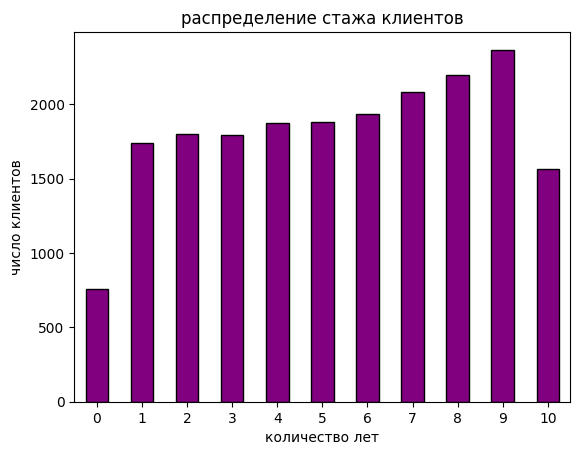

In [44]:
df['Tenure'].value_counts().sort_index().plot(
    kind = 'bar', color = 'purple', edgecolor = 'black'
)
plt.title('распределение cтажа клиентов')
plt.xlabel('количество лет')
plt.ylabel('число клиентов')
plt.xticks(rotation = 0)
plt.show()

аномально больших значений визуально не наблюдаю

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

OK
</div>

## Gender - пол 

In [45]:
print('тип данных:', df['Gender'].dtype)
print('количество пропусков: ', df['Gender'].isna().sum())

тип данных: object
количество пропусков:  0


In [46]:
print('распределение клиентов по уникальным значениям')
df['Gender'].value_counts()

распределение клиентов по уникальным значениям


Gender
Male      10879
Female     9043
na           78
Name: count, dtype: int64

78 клиентов с неопределенным полом, заменять их модой нельзя в данный момент это не пропуск, а отдельное значение. Оставим пропуски как отдельную категорию Uknown

In [47]:
df['Gender'] = df['Gender'].replace('na', 'Uknow')

In [48]:
df['Gender']

0        Female
1          Male
2          Male
3        Female
4        Female
          ...  
19995      Male
19996      Male
19997    Female
19998      Male
19999      Male
Name: Gender, Length: 20000, dtype: object

In [49]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,Satisfaction Score,Card Type,Point Earned,CreditScore_was_missing,Age_was_anomalous,Complain_Yes,Complain_No,Complain_Missing,Satisfaction_Fill,Satisfaction_Provided
0,709.0,France,Female,36.0,4,174056.41,1,1,1,40449.79,...,NaN,SILVER,752,0,0,0,1,0,0.0,0
1,534.0,France,Male,27.0,9,0.00,2,1,0,161344.13,...,NaN,PLATINUM,925,0,0,0,1,0,0.0,0
2,597.0,Spain,Male,24.0,0,108058.07,2,1,1,187826.11,...,NaN,PLATINUM,676,0,0,0,1,0,0.0,0
3,659.0,Germany,Female,26.0,9,84870.44,1,1,1,101371.05,...,NaN,DIAMOND,727,0,0,0,1,0,0.0,0
4,794.0,Spain,Female,28.0,5,0.00,2,0,1,86699.98,...,NaN,DIAMOND,734,0,0,0,1,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,788.0,France,Male,34.0,1,64191.06,2,1,0,37217.73,...,NaN,DIAMOND,222,0,0,0,1,0,0.0,0
19996,576.0,France,Male,42.0,4,137429.76,2,0,0,137330.80,...,NaN,GOLD,740,0,0,0,1,0,0.0,0
19997,711.0,France,Female,29.0,3,130181.47,2,1,0,31811.44,...,NaN,SILVER,719,0,0,0,1,0,0.0,0
19998,647.0,Spain,Male,32.0,9,80958.36,1,1,1,128590.73,...,NaN,GOLD,540,0,0,0,1,0,0.0,0


<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Пропуски пола обработаны корректно.
</div>

## Geography

In [50]:
print('тип данных:', df['Geography'].dtype)
print('количество пропусков: ', df['Geography'].isna().sum())

тип данных: object
количество пропусков:  0


Пропусков нет, тип данных корректный

Проверим уникальные значения, нет ли повторений или разных написаний одного и того же места(например, spain или Spain)

In [51]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

В датасете указаны всего три страны: Франция, Германия и Испания, ничего менять не нужно

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Принято.
</div>

## Итоги предобработки

1) Удаление нереливантных признаков:

    RowNumber, Surname, CustomerID - не влияют на отток

2) Обработка пропусков:

        CreditScore - заполнены медианой (651), создан флаг

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

1. Разные стили оформления списков, скорее всего не корректно прописан markdown.

1. Итоги не полные, возможно забыла, пропустила...
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Действительно, забыла дописать). Сейчас итоги предобработки подвела.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

ОК
</div>

# Разведовочный анализ данных (EDA)

Посмотрим общий отток по базе

In [52]:
total_churn = df['Exited'].mean()
print(f'Доля ушедших клиентов от всего числа: {total_churn:1%}')

Доля ушедших клиентов от всего числа: 20.175000%


Получается, 20% клиентов из датасета ушли

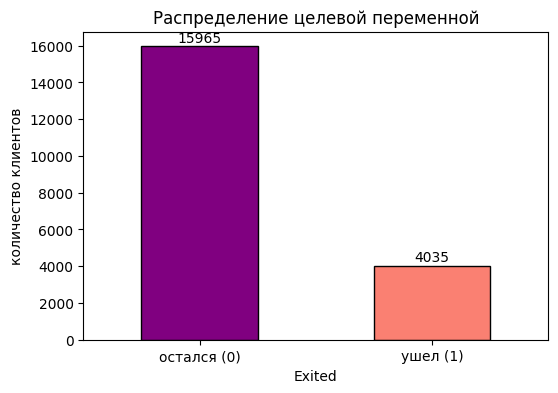

In [53]:
#Распределение целевой переменной Exited:
plt.figure(figsize = (6,4))
df['Exited'].value_counts().plot(kind = 'bar', color = ['purple', 'salmon'], edgecolor = 'black')
plt.title('Распределение целевой переменной')
plt.xticks(ticks = [0,1], labels = ['остался (0)', 'ушел (1)'], rotation = 0)
plt.ylabel('количество клиентов')
for i, v in enumerate(df['Exited'].value_counts()):
    plt.text(i, v + 50, str(v), ha = 'center', va = 'bottom')
plt.show()

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

На график добавлены фактические значения оттока, это гут. Возможно, в данном случае, тип графика `pie` тоже будет хорошо смотреться.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> 🤝. Построила круговую диаграмму.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

ОК
</div>

Построитм тепловую карту на числовых признаках

In [54]:
numeric_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned', 'Tenure', 'Exited']

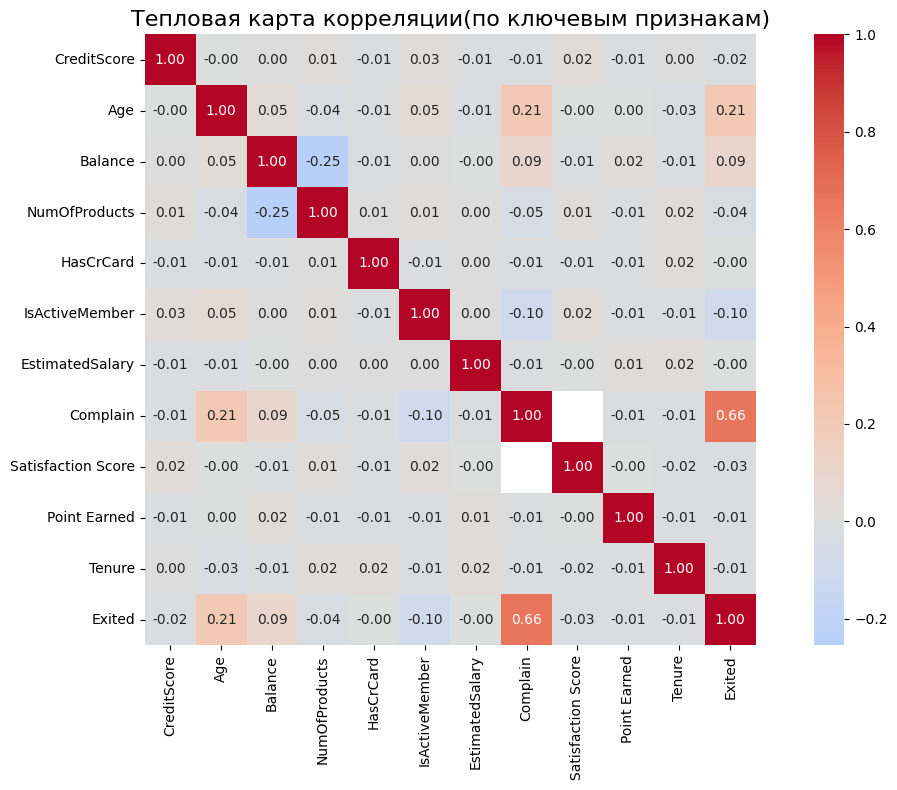

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

#обращаемся к выбранным столбцам
df_numeric = df[numeric_cols]

#считаем корреляцию
corr = df_numeric.corr()

#часть визуализации
plt.figure(figsize = (12,8))
sns.heatmap(corr, 
           annot = True,
           cmap = 'coolwarm',
           center = 0,
           square = True,
           fmt = '.2f')

plt.title('Тепловая карта корреляции(по ключевым признакам)', fontsize = 16)
plt.tight_layout()
plt.show()

На основании тепловой карты мы видим, что зависимости между признаками почти нет, явная зависимость наблюдается только между Complain и Exited, 
получается, жалоба -> почти гарантированный отток.

    IsActiveMember <-> Exited -0.09, зависимость слабая: активные чуть реже уходят.
    
    NumOfProducts <-> Exited -0.04 очень слабая: связи почти нет.
    
    Balance <-> Complain 0.09: чем выше баланс, тем чуть чаще жалуются (возможно, более требовательны)
    
    NumOfProducts <-> Balance -0.25: чем больше продуктов у клиента, тем ниже баланс на счете

    Complain <-> Age 0.21: чем старше клиент, тем больше жалоб.
    
Complain - единственный признак с сильной линейной связью с оттоком. 
Но это не означает, что другие признаки не важны, так как корреляция Пирсона - это линейная зависимость, а в реальности  связь может быть нелинейная

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Корреляционный анализ выполнен. Выявлена сильная связь с жалоб с оттоком.
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Метод `corr()` в pandas, при всей своей простоте использования имеет ряд недостатков, один из них - невозможность проверки корреляционных связей с нечисловыми признаками (https://sky.pro/wiki/analytics/raschet-korrelyatsii-v-pandas-metod-dfcorr()-dlya-analiza-dannyh/#section-4).

Рекомендую посмотреть в сторону библиотеки phik (https://phik.readthedocs.io/en/latest/).
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Согласна, изменила матрицу корреляции.</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Воспользовалась библиотекой `phik`, но для анализа выбрала только числовые признаки.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Действительно🤦‍♀️, добавила остальные признаки.</div>

Теперь рассмотрим ключевые признаки

## EDA IsActiveMember

Гипотеза: если активность не зафиксирована, значит, клиент неактивен или еще не проявил активность
проверим гипотезу, ответим на вопрос 'у клиентов с прпуском в IsActiveMember отток выше, чем у других?'

In [56]:
#сравним уровень оттока по группам
#группируем по флагу пропуска:
churn_by_missing = df.groupby('IsActiveMember')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля ушедших клиентов
).round(3)

print(churn_by_missing)

                count  churn_rate
IsActiveMember                   
0                9309       0.243
1               10691       0.166


Итог проверки:

    *неактивные клиенты уходят с вероятностью 24.3%

    *активные клиенты уходят с вероятностью 16.7%
Неактивные клиенты уходят на 7.6% чаще,чем активные

Это значимая разница - значит, признак IsActiveMember важен для модели

## EDA Satisfaction Score и Complain

In [57]:
#связь с оттоком и Complain
churn_by_Complain = df.groupby('Complain')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_Complain)

          count  churn_rate
Complain                   
0.0       15142       0.066
1.0        4088       0.715


Из тех, кто пожаловался 71% в дальнейшем перестал быть клиентом банка. Из тех, кто не жаловался, ушло всего 6%.

In [58]:
#связь с оттоком и Satisfaction Score
churn_by_Satisfaction = df.groupby('Satisfaction Score')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_Satisfaction)

                    count  churn_rate
Satisfaction Score                   
1.0                   776       0.713
2.0                   849       0.744
3.0                   810       0.712
4.0                   804       0.720
5.0                   849       0.686


Уровень оттока почти не зависит от оценки, логично что при оценке 5.0 меньше клиентов уйдет, чем при оценках ниже,но все же, даже при 5.0 из банка ушло 68%
.

Сравним отток клиентов по двум группам(Complain и Satisfaction Score) среди тех, кто жаловался:

Жаловались и оценили: сравнить у кого отток выше:

оценка ниже средней

оценка выше или равна средней
жаловались,но не оценили - посмотреть каков у них отток

In [59]:
#узнаем какие есть оценки
df['Satisfaction Score'].unique()

array([nan,  5.,  2.,  4.,  3.,  1.])

Получается, что оценивание происходит по 5-балльной шкале

Посмотрим долю ушедших среди тех, кто оценил: 1) ниже среднего, 2) выше\равно среднего

In [60]:
#отфильтруем клиентов, у которых Complain = 1
complain_mask = df['Complain'] == 1
df_complain = df[complain_mask].copy()

#посчитаем среднюю оценку среди тех, кто жаловался и оценил
mean_satisfaction_complain = df_complain['Satisfaction Score'].mean()
print(f'средняя оценка решения жалобы(среди жаловавшихся):{mean_satisfaction_complain:2f}')

#разделим жаловавшихся на группы по оценке

#группа А: жаловались и оценили
df_rated = df_complain[df_complain['Satisfaction Score'].notna()].copy()

#добавим признак: ниже средней оценки?
df_rated['Below_Average_Score'] = df_rated['Satisfaction Score'] < mean_satisfaction_complain

#группа B: жаловались, но не оценили
df_not_rated = df_complain[df_complain['Satisfaction Score'].isna()]

#посчитаем долю ушедших 

# 1. жаловались и оценили ниже среднего
churn_rated_low = df_rated[df_rated['Below_Average_Score']]['Exited'].mean()
count_rated_low = len(df_rated[df_rated['Below_Average_Score']])

# 2. жаловались и оценили выше или равно среднему
churn_rated_high = df_rated[~df_rated['Below_Average_Score']]['Exited'].mean()
count_rated_high = len(df_rated[~df_rated['Below_Average_Score']])

# 3.жаловались, но не оценили
churn_not_rated = df_not_rated['Exited'].mean()
count_not_rated = len(df_not_rated)

#вывод результатов
print('анализ оттока среди клиентов, подавших жалобу (Complain = 1):')
print('-' * 60)
print(f'оценили и ниже среднего ({count_rated_low} чел.): {churn_rated_low:.2%} ушли')
print(f'оценили и выше\равно среднего ({count_rated_high} чел.): {churn_rated_high:.2%} ушли')
print(f'не оценили ({count_not_rated} чел.): {churn_not_rated:.2%} ушли')

средняя оценка решения жалобы(среди жаловавшихся):3.024706
анализ оттока среди клиентов, подавших жалобу (Complain = 1):
------------------------------------------------------------
оценили и ниже среднего (2435 чел.): 72.36% ушли
оценили и выше\равно среднего (1653 чел.): 70.24% ушли
не оценили (0 чел.): nan% ушли


/tmp/ipykernel_412451/2039037694.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x = 'Group', y = 'Churn Rate', palette = 'Set3')


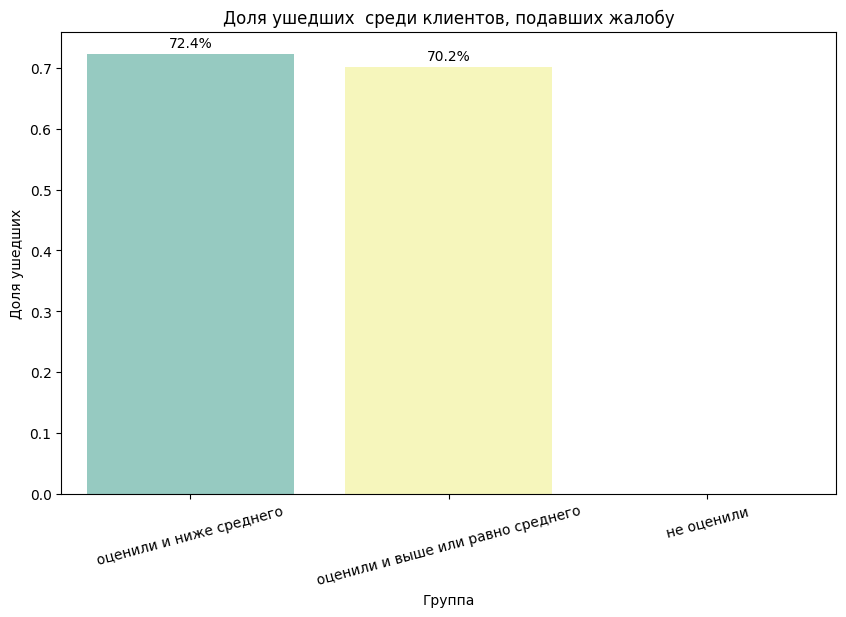

In [61]:
#визуализируем полученные результаты
summary = pd.DataFrame({
    'Group': [
        'оценили и ниже среднего',
        'оценили и выше или равно среднего',
        'не оценили'
    ],
    'Churn Rate': [
        churn_rated_low,
        churn_rated_high,
        churn_not_rated
    ],
    'Count':[
        count_rated_low,
        count_rated_high,
        count_not_rated
    ]
})
plt.figure(figsize = (10,6))
sns.barplot(data=summary, x = 'Group', y = 'Churn Rate', palette = 'Set3')
plt.title('Доля ушедших  среди клиентов, подавших жалобу')
plt.ylabel('Доля ушедших')
plt.xlabel('Группа')
plt.xticks(rotation = 15)
for i, row in summary.iterrows():
    plt.text(i,row['Churn Rate'] + 0.01, f"{row['Churn Rate']:.1%}", ha = 'center')
plt.show()

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

1. При вызове `sns.barplot()` получили предупреждение, что использование параметра `palette` без параметра `hue` устарело и не будет в дальнейшем поддерживаться.

1. В PEP8 рекомендуется не использовать пробелы вокруг знака `=`, если он используется для обозначения именованного аргумента или значения параметров по умолчанию. (https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html#section-11)

Исправляем:
```python
sns.barplot(data=summary, x='Group', y='Churn Rate', palette='Set3', hue='Group')
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> На счет параметра hue поняла, исправила. В будущем постараюсь не ставить пробелы в таких случаях.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

ОК
</div>

Вывод: почти одинаковый отток в обеих группах среди жаловавшихся 

    оценили ниже среднего - 72% ушли 

    оценили выше\равно среднего - 70% ушли

Факт жалобы сам по себе - главный фактор оттока, а не оценка ее решения

Разница всего в 2% - очень маленькая, а значит:

Даже если банк решит проблему и клиент оценил решение высоко, он почти так же часто уходит, как и тот, кто оценил плохо (то есть жалоба = точка невозврата для большинства)

Влияние на модель:

1. Satisfaction Score слабо влияет на отток среди жаловавшихся

2. Самый сильный признак - наличие жалобы

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Хорошее исследование и выводы.
</div>

## EDA Geography

Основываясь на анализе предыдущщих признаков появился вопрос: Высокий отток в Германии - случайность или системная проблема?

In [62]:
print('распределение клиентов по месту проживания')
df['Geography'].value_counts()

распределение клиентов по месту проживания


Geography
France     10117
Germany     4988
Spain       4895
Name: count, dtype: int64

Основная часть клиентов из Франции, другая часть поделилась пополам на Германию и Испанию

In [63]:
#связь с оттоком
churn_by_card = df.groupby('Geography')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_card)

           count  churn_rate
Geography                   
France     10117       0.173
Germany     4988       0.275
Spain       4895       0.187


Клиенты из Германии уходят значительно чаще, чем из Франции или Испании

связь с другими признаками:

In [64]:
#Создадим временные группы
bins = [-1, 0, 50000, 100000, 150000, 200000, 1000000]
labels = ['Zero', 'Low', 'Medium', 'High', 'Very_High', 'Extreme']

df['Balance_group'] = pd.cut(df['Balance'], bins = bins, labels = labels)

#отток по странам и балансу:
df.pivot_table(
    index = 'Geography',
    columns = 'Balance_group',
    values = 'Exited',
    aggfunc = 'mean'
).round(3)

/tmp/ipykernel_412451/1581574095.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


Balance_group,Zero,Low,Medium,High,Very_High,Extreme
Geography,,,,,,
France,0.147,0.181,0.181,0.177,0.212,0.377
Germany,0.188,0.207,0.190,0.347,0.229,0.297
Spain,0.140,0.209,0.217,0.182,0.225,0.315


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

При вызове `df.pivot_table()` получили предупреждение, что значение параметра `observed=False` по умолчанию устарело и в будущей версии pandas будет изменено на `observed=True`. Рекомендуется явно прописать `observed=False`, чтоб отключить данное предупреждение.

Исправляем:
```python
#отток по странам и балансу:
df.pivot_table(
    index='Geography',
    columns='Balance_group',
    values='Exited',
    aggfunc='mean',
    observed=False
).round(3)
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> 🤝 Исправила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

ОК
</div>

В Германии: 

    высокий отток в группе High (100-150k) 34%

    Даже в zero - 18.8%, выше, чем в других странах

    В Extreme - 29.7%(ниже, чем во Франции)

Во Франции:

    Максимальный отток у Extreme (37.7%) (возможно уходят в приватные банки)

В Испании:

    Высокий отток в Very_High и  в Extreme

In [65]:
#страна и количество продуктов:
pd.crosstab(df['Geography'], df['NumOfProducts'], normalize = 'index').round(3)

NumOfProducts,1,2,3,4
Geography,,,,
France,0.492,0.476,0.025,0.007
Germany,0.518,0.443,0.032,0.006
Spain,0.502,0.465,0.027,0.006


В Германии: 

    больше всего клиентов с 1 продуктом (51.8%)

    доля с 3 продуктами - 3.2%, что выше, чем в других странах

In [66]:
#страна и жалобы:
df.groupby('Geography')['Complain'].mean().round(3)

Geography
France     0.179
Germany    0.298
Spain      0.195
Name: Complain, dtype: float64

В Германии в 1.7 раза больше жалоб, чем во Франции. Это является главным сигналом, проблема оттока в Германии не в продуктах или балансе, а в качестве сервиса.

In [67]:
#страна и удовлетворенность после жалобы
df[df['Complain'] == 1].groupby('Geography')['Satisfaction Score'].mean()

Geography
France     3.049568
Germany    2.990909
Spain      3.030336
Name: Satisfaction Score, dtype: float64

Различие незначительное, но все же оценка удовлетворенностью в Германии ниже, чем в других странах.

Получается, клиенты в Германии жалуются чаще и менее довольны решением --> менее довольны решением.

Итоги анализа Geography:

❗❗Германия - ключевой очаг проблемы оттока.

Причины:

    1. Высокая доля жалоб(почти 30% клиентов)

    2. Низкая удовлетворенность после жалоб (2.99)

    3. Рост оттока у клиентов с 3 продуктами и высоким балансом

    4. Высокий отток даже среди тех, кто с 1 продуктом


Ответ на вышепоставленный вопрос: высокий отток в Германии не случайность, а системная проблема

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Замечательное исследование и интересный инсайт.
</div>

## EDA NumOfProducts

Разберем признак 'количество продуктов у клиента'

In [68]:
print('уникальные значения:', df['NumOfProducts'].unique())
print('\nРаспределение значений:')
print(df['NumOfProducts'].value_counts().sort_index())

уникальные значения: [1 2 3 4]

Распределение значений:
NumOfProducts
1    10021
2     9297
3      550
4      132
Name: count, dtype: int64


Половина клиентов с 1 продуктом, с 2 клиентами почти вторая половина и с 3-4 продуктами - единицы.

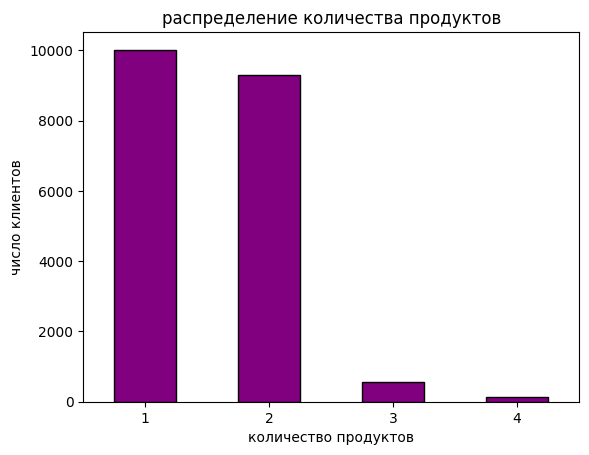

In [69]:
#визуализируем
df['NumOfProducts'].value_counts().sort_index().plot(
    kind = 'bar', color = 'purple', edgecolor = 'black'
)
plt.title('распределение количества продуктов')
plt.xlabel('количество продуктов')
plt.ylabel('число клиентов')
plt.xticks(rotation = 0)
plt.show()

Выставим гипотезу: чем больше продуктов, тем выше лояльность Проверим связь с оттоком

In [70]:
churn_by_products = df.groupby('NumOfProducts')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)
print(churn_by_products)

               count  churn_rate
NumOfProducts                   
1              10021       0.247
2               9297       0.130
3                550       0.505
4                132       0.568


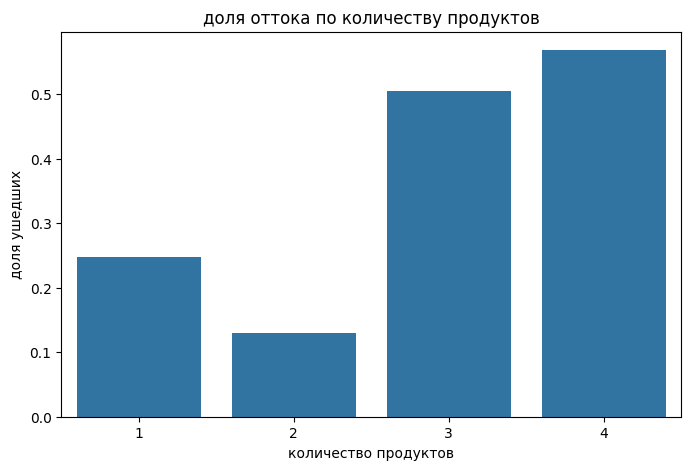

In [71]:
#визуализация
plt.figure(figsize = (8,5))
sns.barplot(data = df, x = 'NumOfProducts', y = 'Exited', errorbar = None)
plt.title('доля оттока по количеству продуктов')
plt.ylabel('доля ушедших')
plt.xlabel('количество продуктов')
plt.show()

Построим тепловую карту той же зависимости, что и выше

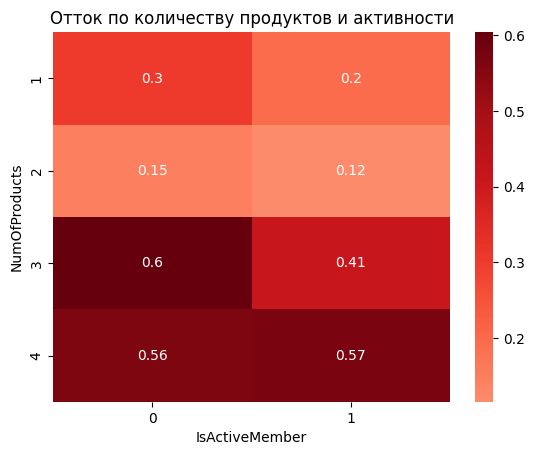

In [72]:
pivot = df.pivot_table(index = 'NumOfProducts', columns = 'IsActiveMember', values = 'Exited', aggfunc = 'mean')
sns.heatmap(pivot, annot = True, cmap = 'Reds', center = 0.2)
plt.title('Отток по количеству продуктов и активности')
plt.show()

получается, что с 1 продуктом отток высокий 24%, но это ожидаемо

с 2 продуктами отток 13%, лояльные клиенты

3 продуктами - отток 50%, это в 4 раза выше,чем у клиентов с 2 продуктами 

4 продуктами - отток 56% - почти каждый второй уходит
Данный анализ показал противоречивость гипотезы, клиенты с большим количеством продуктов абсолютно не лояльны, большой процент оттока, возможно дело в качестве продуктов.

Очень важный признак для модели.

Посмотрим связь с активностью, клиенты с 3-4 продуктами - они активны или нет?

In [73]:
pd.crosstab(df['NumOfProducts'], df['IsActiveMember'], normalize = 'index').round(3)

IsActiveMember,0,1
NumOfProducts,,
1,0.475,0.525
2,0.453,0.547
3,0.496,0.504
4,0.470,0.530


Значимой разницы нет

Рассмотрим связь с жалобами и оттоком

In [74]:
churn_by_complain = df.groupby(['NumOfProducts','Complain'])['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)
print(churn_by_complain)

                        count  churn_rate
NumOfProducts Complain                   
1             0.0        7117       0.071
              1.0        2532       0.754
2             0.0        7710       0.060
              1.0        1204       0.579
3             0.0         253       0.099
              1.0         285       0.884
4             0.0          62       0.129
              1.0          67       0.955


Клиенты с 2-мя продуктами самые лояльные: при наличии жалобы уходят в 50% случаев, при остальных количествах продуктов клиент при наличии жалобы уйдет при вероятности более 80%

Распределение клиентов по странам и количеству продуктов:

In [75]:
crosstab_geo = pd.crosstab(df['NumOfProducts'], df['Geography'], normalize = 'index')*100
crosstab_geo.round(1)

Geography,France,Germany,Spain
NumOfProducts,,,
1,49.7,25.8,24.5
2,51.8,23.7,24.5
3,46.5,29.5,24.0
4,53.0,24.2,22.7


In [76]:
crosstab_geo.columns.tolist()

['France', 'Germany', 'Spain']

✔Франция - лидер по охвату

    50-53%% всех клиентов с 1-4 продуктами

✔Германия - растет с количеством продуктов

    у клиентов с 1  продуктом 25%, с 3 продуктами 29,5%

✔Испания - не лидер

    всегда примерно 24% клиентов, неза/висимо от количества продуктов

Ранее мы заметили что в Германии самый высокий отток: 27,5%, во Франции и в Испании 17,3% и 18,7% соотвенственно.

Высокий отток в Германии - не потому, что у них больше продуктов, возможно в Германии высокий отток из-за качества сервиса или проблем удержания после продаж

Ключевые выводы по NumOfProducts:

❗Клиенты с 3-4 продуктами уходят в 50% случаев

❗Больше всего продуктами (1-4) интересуются во Франции(50% при любом количестве продуктов)

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Просто бальзам на душу аналитика, такие исследования. Даже без построения модели, для бизнеса есть важная информация для борьбы с оттоком.
</div>

## EDA HasCrCard

In [77]:
print('распределение')
print(df['HasCrCard'].value_counts().sort_index())

распределение
HasCrCard
0     5856
1    14144
Name: count, dtype: int64


примерно 75% клиентов имеют кредитную карту

Проверим связь с оттоком

In [78]:
churn_by_card = df.groupby('HasCrCard')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_card)

           count  churn_rate
HasCrCard                   
0           5856       0.204
1          14144       0.201


Наличие кредитной карты не влияет на уход, клиенты уходят с одинаковой вероятностью, признак не значимый

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

OK
</div>

## EDA Card Type

In [79]:
#уникальные значения
print('Уникальные значения и распределение: ')
print(df['Card Type'].value_counts())

Уникальные значения и распределение: 
Card Type
DIAMOND     5077
PLATINUM    5017
GOLD        4984
SILVER      4922
Name: count, dtype: int64


Типы карт равнораспределены

In [80]:
#проверим связь с оттоком:
churn_by_card = df.groupby('Card Type')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_card)

           count  churn_rate
Card Type                   
DIAMOND     5077       0.209
GOLD        4984       0.194
PLATINUM    5017       0.201
SILVER      4922       0.203


Уход клиентов также не зависит от типа карты

## EDA Point Earned

In [81]:
#Связь с оттоком
#разобьем на группы
bins = [0, 400, 700, 1000]
labels = ['Low (119-400)', 'Medium (401-700)', 'High(701-1000)']
df['Points_Group'] = pd.cut(df['Point Earned'], bins = bins, labels = labels)

#проверим отток
churn_by_points = df.groupby('Points_Group')['Exited'].agg(
    counts = 'size',
    churn_rate = 'mean'
).round(3)
print(churn_by_points)

                  counts  churn_rate
Points_Group                        
Low (119-400)       4680       0.210
Medium (401-700)    7285       0.201
High(701-1000)      8035       0.198


/tmp/ipykernel_412451/1512076976.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_points = df.groupby('Points_Group')['Exited'].agg(


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Уже известная нам проблема при вызове `df.pivot_table()`, исправляем с помощью добавления `observed=False`.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> 🤝 Исправила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Есть небольшая тенденция: чем выше быллы, тем ниже отток, но разница маленькая 
Програма лояльности слабо влияет на удержание

## EDA Tenure

связь с оттоком - ключевой вопрос

In [82]:
churn_by_card = df.groupby('Tenure')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_card)

        count  churn_rate
Tenure                   
0         759       0.216
1        1743       0.217
2        1802       0.185
3        1793       0.213
4        1877       0.198
5        1882       0.204
6        1935       0.205
7        2081       0.187
8        2195       0.200
9        2367       0.196
10       1566       0.214


наибольший отток у новичков (0 лет и 1 год) и у 10 летних клиентов

наименьший отток на 2 и 7 году

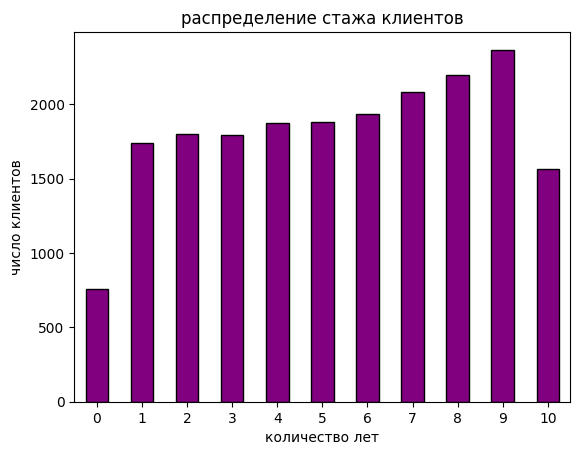

In [83]:
df['Tenure'].value_counts().sort_index().plot(
    kind = 'bar', color = 'purple', edgecolor = 'black'
)
plt.title('распределение cтажа клиентов')
plt.xlabel('количество лет')
plt.ylabel('число клиентов')
plt.xticks(rotation = 0)
plt.show()

распределение не равномерное, с пиком на 9-м гому, новых клиентов не слишком много

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Интересно, почему 10 лет максимум?!
</div>

## EDA Gender

In [84]:
#связь с оттоком
churn_by_Gender = df.groupby('Gender')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean' #доля клиентов, которые ушли
).round(3)
print(churn_by_Gender)

        count  churn_rate
Gender                   
Female   9043       0.231
Male    10879       0.177
Uknow      78       0.205


Женщины уходят немного чаще, чем мужчины, данный признак нельзя назвать значимым

In [85]:
df.pivot_table(index = 'Gender', columns = 'IsActiveMember', values = 'Exited', aggfunc = 'mean').round(3)

IsActiveMember,0,1
Gender,,
Female,0.275,0.192
Male,0.216,0.144
Uknow,0.226,0.191


Женщины уходят чаще, чем мужчины, вне звисимости от активности

In [86]:
#средний и медианный баланс
balance_by_gender = df.groupby('Gender')['Exited'].agg(
    count = 'size',
    mean_balance = 'mean',
    median_balance = 'median' 
).round(3)
print(balance_by_gender)

        count  mean_balance  median_balance
Gender                                     
Female   9043         0.231             0.0
Male    10879         0.177             0.0
Uknow      78         0.205             0.0


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Среднее и количество мы получили двумя ячейками выше, не понял, зачем тут медиана? 
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Действительно, мы это получили выше, видимо добавляла эту часть кода когда уже закончила раздел EDA и не посмотрела, что рассчитывала их выше, удалю этот код.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

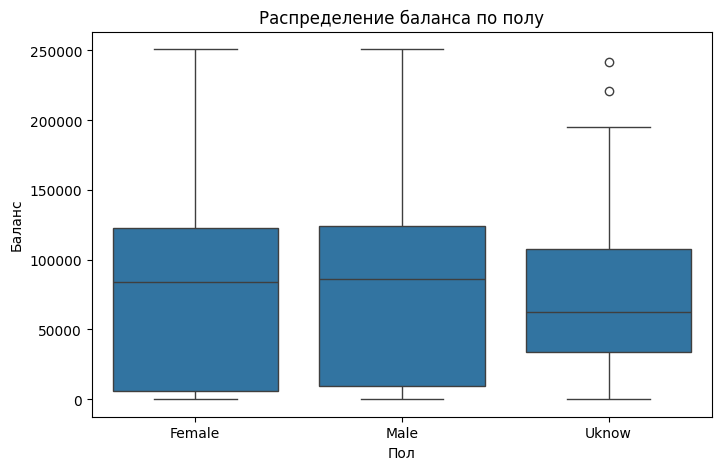

In [87]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = df, x = 'Gender', y = 'Balance')
plt.title('Распределение баланса по полу')
plt.ylabel('Баланс')
plt.xlabel('Пол')
plt.show()

Hаспределение баланса по полу визуально не отличается

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

ОК - Выяснили, что различия по полу есть, но не значительные.
</div>

## EDA Balance

Цель: у кого из клиентов самый большой отток? У бедных или у богатых? Есть ли U-образная зависимость? Как Balance связан с другими признаками?

In [88]:
#описательная статистика:
df['Balance'].describe()

count     20000.000000
mean      77543.121707
std       59293.459743
min           0.000000
25%        8457.702500
50%       85150.295000
75%      123684.380000
max      250898.090000
Name: Balance, dtype: float64

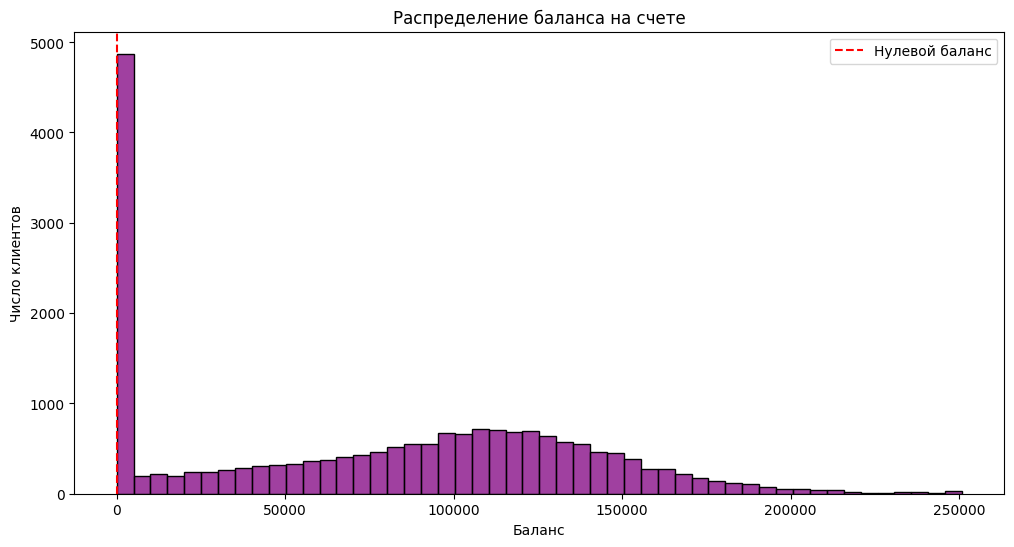

In [89]:
#распределение: гистограмма

plt.figure(figsize = (12, 6))
sns.histplot(df['Balance'], bins = 50, color = 'purple', edgecolor = 'black')
plt.title('Распределение баланса на счете')
plt.xlabel('Баланс')
plt.ylabel('Число клиентов')
plt.axvline(x = 0, color = 'red', linestyle = '--', label = 'Нулевой баланс')
plt.legend()
plt.show()

Гистограмма Balance имеет резкий пик на нуле(~4900 клиентов), что соответствует неактивным клиентам. Далее, от 0 до 120 000 баланса, количество 
клиентов плавно растет, достигая максимума(1000), после чего плавно стремится к нулю при балансе ~200000.

    Пик на 120 000 - оптимальный уровень сбережений

    Падение после - мало богатых клиентов.

Распределение не нормальное, но отражает реальную структуру клиентов.

Посчитаем отток по группам

In [90]:
#Создадим временные группы
bins = [-1, 0, 50000, 100000, 150000, 200000, 1000000]
labels = ['Zero', 'Low', 'Medium', 'High', 'Very_High', 'Extreme']

df['Balance_group'] = pd.cut(df['Balance'], bins = bins, labels = labels)

#теперь посмотрим кто чаще уходит
churn_by_balance = df.groupby('Balance_group')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)

churn_by_balance

/tmp/ipykernel_412451/2283704923.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_balance = df.groupby('Balance_group')['Exited'].agg(


,count,churn_rate
Balance_group,,
Zero,4693,0.146
Low,2440,0.192
Medium,4618,0.192
High,6134,0.245
Very_High,1854,0.222
Extreme,261,0.322


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Ты уже знаешь что делать с `observed=False`, больше не буду напоминать.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> 🤝</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Наблюдается интересная зависимость: чем выше баланс, тем больше отток. Построим визуализацию

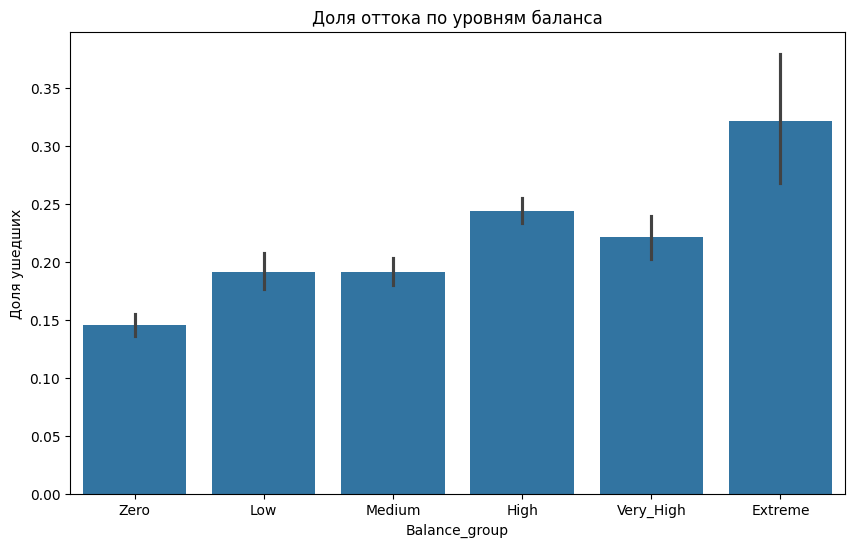

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
sns.barplot(data = df, x = 'Balance_group', y = 'Exited')
plt.title('Доля оттока по уровням баланса')
plt.ylabel('Доля ушедших')
plt.xticks(rotation = 0)
plt.show()

Действительно, форма зависимости - не U-образная, а возрастающая в конце, пик на Extreme.
    
Клиенты с самым высоким балансом уходят больше чем в 2 раза чаще чем те, у кого нулевой баланс.

Это может указывать на проблему удержания богатых клиентов

Посмотрим отток по балансу и активности

/tmp/ipykernel_412451/3806753872.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


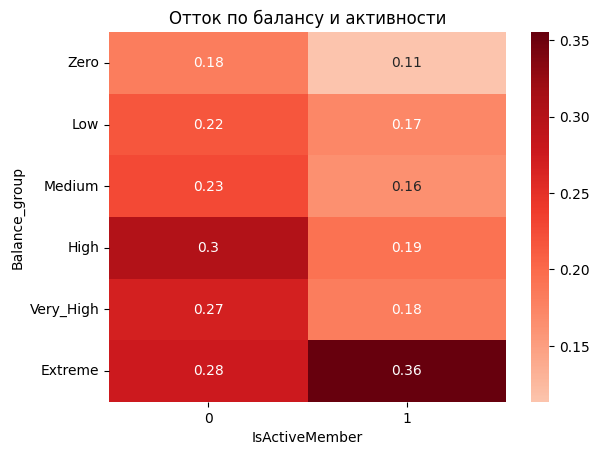

In [92]:
pivot = df.pivot_table(
    index = 'Balance_group',
    columns = 'IsActiveMember',
    values = 'Exited',
    aggfunc = 'mean'
)
sns.heatmap(pivot, annot = True, cmap = 'Reds', center = 0.2)
plt.title('Отток по балансу и активности')
plt.show()

Интересный момент, который может подтверждать проблему, поднятую выше: основная часть из ушедших это клиенты с большим балансом и 
положительной активностью

In [93]:
pd.crosstab(df['Balance_group'], df['Geography'], normalize = 'index').round(3)

Geography,France,Germany,Spain
Balance_group,,,
Zero,0.683,0.024,0.294
Low,0.602,0.170,0.228
Medium,0.485,0.267,0.248
High,0.396,0.392,0.212
Very_High,0.381,0.369,0.250
Extreme,0.264,0.529,0.207


Клиенты с самым высоким балансом из Германии(52.9%), при этом, в другим группах Германия 2%-27%. В Германии не просто высокий отток, а
высокий отток у самых богатых и активных клиентов

Итог по Balance:

1) Распределение необычное

    резкий пик на нуле, затем плавный рост до 120 000 и плавное падение

❗2) Самый высокий отток - у клиентов с экстремально высоким балансом (32% - каждый третий уходит)

    Особенно среди активных клиентов из Германии


<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Отличное исследование.
</div>

## EDA Age

Цель: понять кто из возврастных групп уходит чаще. Есть ли U-образная зависимость? Как возраст связан с Balance, NumOfProducts и Exited

In [94]:
df['Age'].describe()

count    20000.000000
mean        37.966750
std          9.582204
min         18.000000
25%         32.000000
50%         37.000000
75%         42.000000
max         92.000000
Name: Age, dtype: float64

Средний возраст - 38 лет, разброс умеренный.

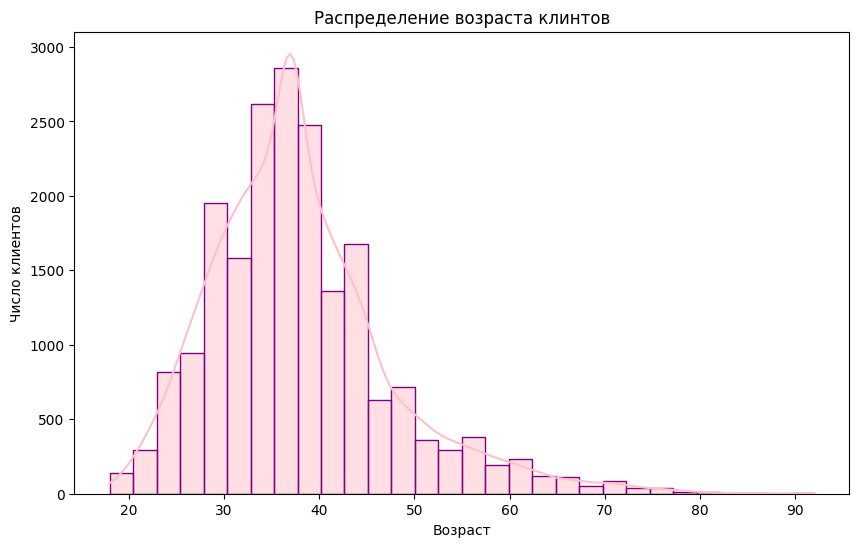

In [95]:
plt.figure(figsize = (10,6))
sns.histplot(df['Age'], bins = 30, kde = True, color = 'pink', edgecolor = 'purple')
plt.title('Распределение возраста клинтов')
plt.xlabel('Возраст')
plt.ylabel('Число клиентов')
plt.show()

Пик в районе 30-40 - типично для массового банка. Хвост вправо - есть возрастные клиенты.

In [96]:
#группировка по возрасту
bins = [18, 30, 40 ,50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '60+']
df['Age_group'] = pd.cut(df['Age'], bins = bins, labels = labels)

#отток по возрастным группам
churn_by_age = df.groupby('Age_group')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)

churn_by_age


/tmp/ipykernel_412451/3402218903.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = df.groupby('Age_group')['Exited'].agg(


,count,churn_rate
Age_group,,
18-30,4115,0.101
31-40,9526,0.164
41-50,4389,0.290
51-60,1317,0.460
60+,624,0.272


U-образной зависимости нет.

У молодых клиентов отток минимальный, а далее с ростом возраста растет и отток. У клиентов возрастной группы 51-60 отток 46%(почти половина уходит) - самая рискованная группа.

Посмотрим связь с другими признаками

Связь с активностью:

In [97]:
df.pivot_table(index = 'Age_group', columns = 'IsActiveMember', values = 'Exited', aggfunc = 'mean').round(3)

/tmp/ipykernel_412451/2315381663.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'Age_group', columns = 'IsActiveMember', values = 'Exited', aggfunc = 'mean').round(3)


IsActiveMember,0,1
Age_group,,
18-30,0.116,0.087
31-40,0.185,0.147
41-50,0.350,0.234
51-60,0.639,0.323
60+,0.623,0.153


❗❗У неактивных (0) отток катастрофически высок:

    В 51-60: 63.9%

    В 60+: 62.3%

У активных (1) - отток в 2-3 раза ниже, но все равно растет с возрастом.

Посмотрим связь с балансом

In [98]:
df.groupby('Age_group')['Balance'].mean().round(0)

/tmp/ipykernel_412451/1553185054.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_group')['Balance'].mean().round(0)


Age_group
18-30    74858.0
31-40    75428.0
41-50    81371.0
51-60    86781.0
60+      80866.0
Name: Balance, dtype: float64

У клиентов 50+ баланс чуть выше (на 5-10 тыс)

In [99]:
corr = df['Age'].corr(df['Tenure'])
corr

np.float64(-0.02695241239938747)

связи нет

In [100]:
#связь с количествоим продуктов
df.groupby('Age_group')['NumOfProducts'].mean().round(0)

/tmp/ipykernel_412451/2733515319.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_group')['NumOfProducts'].mean().round(0)


Age_group
18-30    2.0
31-40    2.0
41-50    2.0
51-60    1.0
60+      1.0
Name: NumOfProducts, dtype: float64

18-50 лет: в среднем 2 продукта -> вовлеченность.

51-60+ лет: в реднем 1 продукт -> низкая вовлеченность.

Возрастные клиенты:

    1. используют только один продукт

    2. часто неактивны

    3. уходят в 60-64% случаев, если неактивны.


Ключевой фактор риска - не сам возраст, а сочетание:

    ✔возраст 50+

    ✔один продукт

    ✔низкая активность

Клиенты этой группы мало вовлечены, не используют преимущества банка, и массово уходят.

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Хороший анализ.
</div>

## CreditScore

In [101]:
df['CreditScore'].describe()

count    20000.000000
mean       649.680550
std         88.812102
min        350.000000
25%        596.000000
50%        651.000000
75%        705.000000
max        850.000000
Name: CreditScore, dtype: float64

Разброс небольшой, медиана и среднеее почти одинаковые. Построим гистограмму распределения

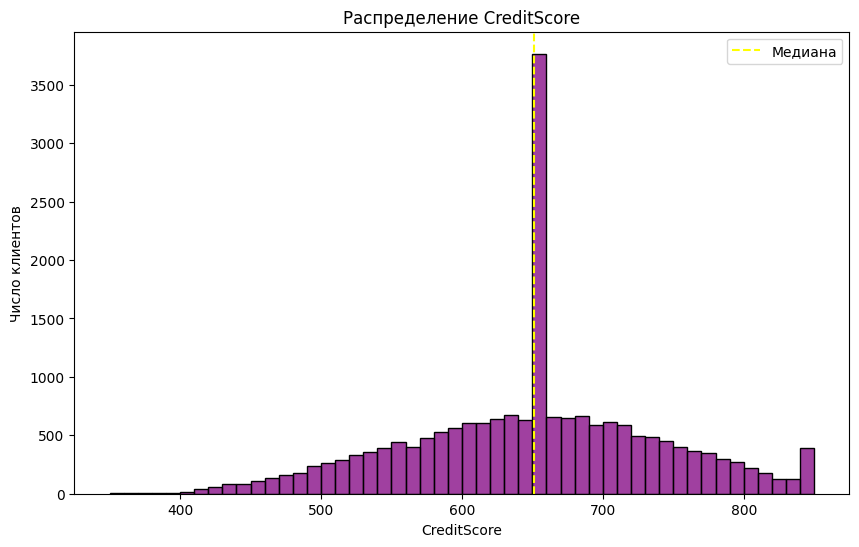

In [102]:
plt.figure(figsize = (10,6))
sns.histplot(df['CreditScore'], bins = 50, color = 'purple', edgecolor = 'black')
plt.title('Распределение CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Число клиентов')
plt.axvline(x = 651, color = 'yellow', linestyle = '--', label = 'Медиана')
plt.legend()
plt.show()

Можно заметить пик на медиане(651) - это искуственный пик из-за заполнения пропусков

Форма в целом нормальная, но с плечом слева

группировка по уровням рейтинга

In [103]:
#временные группы
bins = [300, 580, 670, 740, 850]
labels = ['Low (<580)', 'Fair (580 -669)', 'Good(670-739)', 'Excellent (740+)']
df['CreditScore_group'] = pd.cut(df['CreditScore'], bins = bins, labels = labels)

#отток по группам
churn_by_credit = df.groupby('CreditScore_group')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)

print('отток по уровню кредитного рейтинга: ')
print(churn_by_credit)

отток по уровню кредитного рейтинга: 
                   count  churn_rate
CreditScore_group                   
Low (<580)          4130       0.215
Fair (580 -669)     8698       0.206
Good(670-739)       4039       0.185
Excellent (740+)    3133       0.195


/tmp/ipykernel_412451/3418628191.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_credit = df.groupby('CreditScore_group')['Exited'].agg(


Наибольший отток у клиентов с низким рейтингом (21.5%). Наименьший - у тех, у кого хороший рейтинг(670 - 739: 18.5%)

Посмотрим связь с другими признаками

In [104]:
#Связь с Balance
df.groupby('CreditScore_group')['Balance'].mean().round(2)

/tmp/ipykernel_412451/411361578.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditScore_group')['Balance'].mean().round(2)


CreditScore_group
Low (<580)          74641.82
Fair (580 -669)     81226.23
Good(670-739)       73643.53
Excellent (740+)    76169.73
Name: Balance, dtype: float64

Самый высокий баланс у группы Fair, у остальных ~74-76к.
Клиенты со средним рейтингом имеют наибольший баланс, возможно, это основной сегмент банка.

In [105]:
#Связь с NumOfProducts
df.groupby('CreditScore_group')['NumOfProducts'].mean().round(2)

/tmp/ipykernel_412451/2405502926.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditScore_group')['NumOfProducts'].mean().round(2)


CreditScore_group
Low (<580)          1.53
Fair (580 -669)     1.54
Good(670-739)       1.54
Excellent (740+)    1.55
Name: NumOfProducts, dtype: float64

Количество продуктов одинаковое, нет связи рейтинга с вовлеченностью

In [106]:
#Связь с Complain
df.groupby('CreditScore_group')['Complain'].mean().round(2)

/tmp/ipykernel_412451/32977782.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditScore_group')['Complain'].mean().round(2)


CreditScore_group
Low (<580)          0.22
Fair (580 -669)     0.22
Good(670-739)       0.20
Excellent (740+)    0.21
Name: Complain, dtype: float64

Жалобы распределены равномерно - не зависят от уровня кредитного рейтинга

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Выяснили, что CreditScore, для прогнозирования оттока скорее бесполезен, чем полезен.
</div>

## EDA EstimatedSalary

Есть ли связь между оценкой дохода и оттоком? 

Можно ли использовать этот признак в модели?

Не является ли он искусственным или заполненным заглушками?

In [107]:
df['EstimatedSalary'].describe()

count    2.000000e+04
mean     1.363442e+05
std      3.541847e+05
min     -1.993075e+05
25%      5.691282e+04
50%      1.013711e+05
75%      1.449297e+05
max      5.123361e+06
Name: EstimatedSalary, dtype: float64

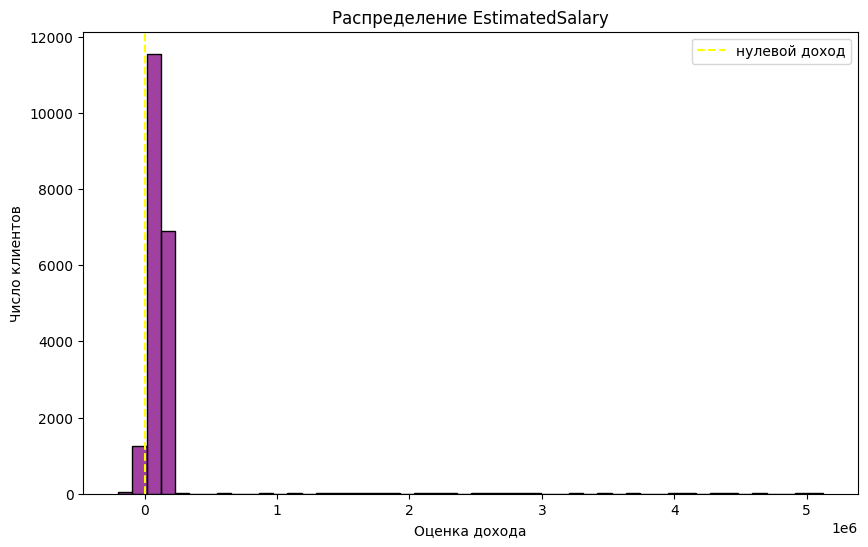

In [108]:
plt.figure(figsize = (10,6))
sns.histplot(df['EstimatedSalary'], bins = 50, color = 'purple', edgecolor = 'black')
plt.title('Распределение EstimatedSalary')
plt.xlabel('Оценка дохода')
plt.ylabel('Число клиентов')
plt.axvline(x = 0, color = 'yellow', linestyle = '--', label = 'нулевой доход')
plt.legend()
plt.show()

In [109]:
#отток по группам дохода:
bins = [-40000, 0, 50000, 100000, 150000, 200000]
labels = ['Negative', 'Zero', 'Low', 'Medium', 'High']
df['Salary_group'] = pd.cut(df['EstimatedSalary'], bins = bins, labels = labels)

#посмотрим на отток:
#отток по группам
churn_by_salary = df.groupby('Salary_group')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)

print('отток по оценке дохода: ')
print(churn_by_salary)

отток по оценке дохода: 
              count  churn_rate
Salary_group                   
Negative         17       0.176
Zero           4344       0.200
Low            4224       0.200
Medium         6809       0.202
High           4264       0.208


/tmp/ipykernel_412451/724758771.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_salary = df.groupby('Salary_group')['Exited'].agg(


нет четкой зависимости между доходом и оттоком. 

In [110]:
corr = df['EstimatedSalary'].corr(df['Balance'])
corr

np.float64(-0.0006502397143677839)

связи EstimatedSalary и Balance нет

In [111]:
df.groupby('Salary_group')['CreditScore'].mean().round(0)

/tmp/ipykernel_412451/2629662023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Salary_group')['CreditScore'].mean().round(0)


Salary_group
Negative    650.0
Zero        651.0
Low         649.0
Medium      648.0
High        651.0
Name: CreditScore, dtype: float64

Рейтинг практически совпадает у всех - значит, EstimatedSalary не отражает реальный статус.

In [112]:
df.groupby('Salary_group')['NumOfProducts'].mean().round(2)

/tmp/ipykernel_412451/4178620838.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Salary_group')['NumOfProducts'].mean().round(2)


Salary_group
Negative    1.41
Zero        1.53
Low         1.54
Medium      1.54
High        1.54
Name: NumOfProducts, dtype: float64

Количество продуктов одинаковое

Анализ EstimatedSalary показал, что данный признак абсолютно неинформативен, его лучше не включать в модель.

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Оценка и вывод вполне логичны.
</div>

## портрет

несколько портретов клиента оттока:

1) "перегруженный" клиент с 3-4 продуктами
    возраст: 40-50
    количество продуктов:3-4
    баланс: средний или низкий
    активность: неактивный или слабо активный
    география: Гемания
    жалоба: была
    удовлетворенность: 1-2
отток: до 60%
возможно, банк 'навязал' продукты, но не дал поддержки

2) Возрастной и забытый
    возраст: 51-60
    продукты: 1
    активность: неактивный
    баланс: средний
отток до 64%
клиент 'забыт' банком, не получает предложений

3)Богатый и недовольный
    баланс: очень высокий (более 200к)
    активность: активный
    география: Германия
    жалоба: была
    удовлетворенность: низкая
отток до 36%
Клиент ценный, но не получает персонального сервиса

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Хромает markdown, желательно поправить.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Исправила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

## Итог EDA

На основе полного анализа датасета из 20 000 клиентов выявлены ключевые драйверы оттока и сформирован портрет клиента, склонного к уходу.

    1. Общая картина оттока 

        - общий уровень оттока: 20.2%

        - распределение неравномерное: есть группы с оттоком до 64% и такие, где он ниже 15%

    ❗отток - не случайность, а результат конкретных проблем в обслуживании и стратегии продаж

    2. Портрет клиента оттока: 4 основных сценария:

        а) Перегруженный клиент

               - 3-4 продукта, возраст 40-50 лет, Германия, неактивный, жаловался ----> ❗ОТТОК до 60%❗

        б) Богатый, но недовольный 

               - баланс >200к, активный, Германия, жаловался ----> ❗ОТТОК до 36%❗

        в) Возрастной и забытый 

               - возраст 51-60 лет, 1 продукт, неактивный ----> ❗ОТТОК до 64%❗

        г) Молодой новичок 

               - возраст 18-30 лет, стаж 0-1 год, 1 продукт, неактивный ----> ❗ОТТОК до 21%❗

    3. Ключевые драйверы оттока

        Complain = 1 ----> самый сильный сигнал: отток 70-80%, жалоба = почти гарантированный уход

        IsActiveMember = 0 ----> неактивные уходят в 3-4 раза чаще, чем активные

        NumOfProducts >= 3 ----> не лояльность, а перегрузка: клиенты переполнены продуктами, но недовольны

        Geography = Germany ----> самый высокий отток(27.5%), особенно среди богатых и многопродуктовых клиентов

        Balance = Extreme(>200k) ----> уходят самые уенные клиенты - банк теряет VIP-сегмент

        Age = 51-60 + неактивность ----> отток до 64% - клиенты забыты банком

        Stisfaction Score = 1-2 ----> почти 100% уходят. Но многие с жалобами не оценивают, риск "молчаливого ухода"

    4. Проблемы в данных 

        EstimatedSalary: неинформативен, много нулей и отрицательных значений, следует исключить из модели

    5. Инсайты и парадоксы:

        1) Высокий баланс =! лояльность:

            Клиенты с самым высоким балансом уходят чаще - нет персонального подхода.

        2) Много продуктов =! лояльность

            3-4 продукта - признак перегрузки, а не вовлеченности

        3) Германия - главный очаг проблемы

            Высокие жалобы (29.8%), низкая удовлетворенность (2.99%), рост оттока у VIP клиентов

        4) Пик оттока - не у молодых, а у пожилых неактивных

            64% уходят, если им 51-60 и они не пользуются банком

    6. Рекомендации для маркетинга и сервиса:

        1) Ввести персональных менеджеров:

            - для клиентов с 3+ продуктами

            - для тех, у кого баланс >150k

            - особенно в Германии

        2) Активная работа  с жалобами:

            - Решение проблемы в кратчайшие сроки

            - автоматический бонус после жалобы

        3) Удержание возрастных клиентов:

            - персональные предложения для неактивных 50+

            - юбилейные бонусы (10 лет с банком)

        4) Не навязывать продукты:

            - фокус на качество, а не на количество

        5) Улучшить сервис в Германии:

            - улучшить поддержку

            -проверка качества решения жалоб




<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Молодец, получился хороший и полезный анализ выводы. Выявлены интересные зависимости и инсайты.

Выводы можно "причесать", оформить презентацию и отправлять в отдел маркетинга.
</div>

# Биннинг и WOE

1) Разобьем числовые признаки на логичные группы(бины)

2) Для каждого бина посчитаем WOE чтобы оценить влияние на отток

3) Посчитаем IV, чтобы понять какие признаки важны

4) Заменим исходные признаки на WOE-значения для улучшения модели

In [113]:
#подготовка 

df_clean = df.copy()

In [114]:
def calc_woe_iv(df, col, target = 'Exited'):

    #группируем по категории/бину
    woe_df = df.groupby(col)[target].agg(['count', 'sum'])
    woe_df.columns = ['total', 'churned']
    woe_df['non_churned'] = woe_df['total'] - woe_df['churned']

    #доли в группах
    total_non = woe_df['non_churned'].sum() #все оставшиеся
    total_churn = woe_df['churned'].sum() #все ушедшие

    #избегаем деления на 0
    woe_df['dist_non'] = woe_df['non_churned'] / (total_non + 10**(-6))
    woe_df['dist_churn'] = woe_df['churned'] / (total_churn + 10**(-6))

    #WOE
    woe_df['woe'] = np.log(woe_df['dist_non'] / woe_df['dist_churn'])

    #WOE
   # woe_df['woe'] = np.log((non_churned / total_non) / (churned / total_churn))
    
    #заменим бесконечности на 0 (если нет хороших/плохих)
    woe_df['woe'] = woe_df['woe'].replace([np.inf, -np.inf], 0)

    #IV
    woe_df['iv'] = (woe_df['dist_non'] - woe_df['dist_churn']) * woe_df['woe']
    iv = woe_df['iv'].sum()

    return woe_df[['woe']], iv


In [115]:
# не домашняя функция

#def calc_woe_iv(df, col, target = 'Exited'):

    #группируем по категории/бину
 #   woe_df = df.groupby(col)[target].agg(['count', 'sum'])
  #  woe_df.columns = ['total', 'churned']
   # woe_df['non_churned'] = woe_df['total'] - woe_df['churned']

    #доли в группах
    #small_value = 0.0001
    #total_non = woe_df['non_churned'].sum() #все оставшиеся
    #total_churn = woe_df['churned'].sum() #все ушедшие

   # woe_df['dist_non'] = woe_df['non_churned'] / total_non
   # woe_df['dist_churn'] = woe_df['churned'] / total_churn

    #WOE
    #woe_df['woe'] = np.log(woe_df['dist_non'] / woe_df['dist_churn'])

    #IV
    #woe_df['iv'] = (woe_df['dist_non'] - woe_df['dist_churn']) * woe_df['woe']
    #iv = woe_df['iv'].sum()

    #return woe_df[['woe']], iv

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Закомментированный код лучше удалять.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Удалила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

In [116]:
#разделим данные на train/test
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_clean, test_size = 0.25, random_state = 42, stratify = df_clean['Exited'])

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

После разбиения на выборки желательно убедиться, что доля положительных Exited, в выборках одинаковая.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Проверила, одинаковая.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Биннинг числовых признаков


### биннинг возраста

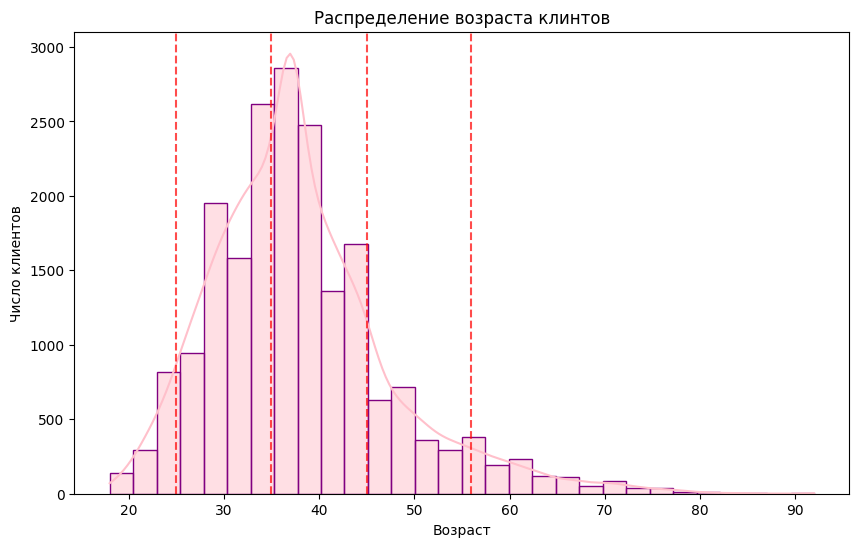

In [117]:
plt.figure(figsize = (10,6))
sns.histplot(df_clean['Age'], bins = 30, kde = True, color = 'pink', edgecolor = 'purple')
plt.title('Распределение возраста клинтов')
plt.xlabel('Возраст')
plt.ylabel('Число клиентов')
plt.axvline(x = 25, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 35, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 45, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 56, color = 'red', linestyle = '--', alpha = 0.7)
plt.show()

In [118]:
#посмотрим размеры выбранных групп:
bins = [18, 25, 35, 45, 56, 100]
labels = ['18-25', '26-35', '36-45', '46-56', '57+']
df['Age_bin_custom'] = pd.cut(df['Age'], bins = bins, labels = labels)
df['Age_bin_custom'].value_counts().sort_index()

Age_bin_custom
18-25    1218
26-35    7094
36-45    8369
46-56    2262
57+      1028
Name: count, dtype: int64

Размер групп нормальный, во всех группах не менне 5%  значений от всего датасета

Посмотрим отток по этим группам

In [119]:
churn_by_age = df.groupby('Age_bin_custom')['Exited'].agg(
    count = 'size',
    churn_rate = 'mean'
).round(3)

churn_by_age

/tmp/ipykernel_412451/1159379938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = df.groupby('Age_bin_custom')['Exited'].agg(


,count,churn_rate
Age_bin_custom,,
18-25,1218,0.088
26-35,7094,0.121
36-45,8369,0.211
46-56,2262,0.424
57+,1028,0.330


Отток растет с возрастом, особенно после 46 лет, группе 57+ отток немного снижается, но все равно высокий. Выберем такие границы для биннинга 
признака Age

In [120]:
#биннинг для возраста
bins_age = [18, 25, 35, 45, 56, 100]
labels_age = ['18-30', '31-40', '41-50', '51-60', '60+']
df_train['Age_bin_custom'] = pd.cut(df_train['Age'], bins = bins_age, labels = labels_age, include_lowest = True)
df_test['Age_bin_custom'] = pd.cut(df_test['Age'], bins = bins_age, labels = labels_age, include_lowest = True)

### биннинг по уровню баланса

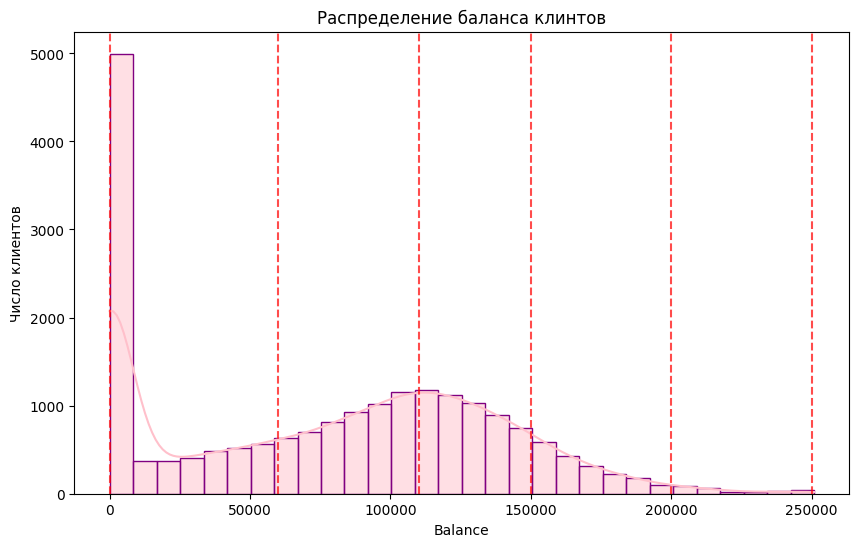

In [121]:
plt.figure(figsize = (10,6))
sns.histplot(df_clean['Balance'], bins = 30, kde = True, color = 'pink', edgecolor = 'purple')
plt.title('Распределение баланса клинтов')
plt.xlabel('Balance')
plt.ylabel('Число клиентов')
plt.axvline(x = 0, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 60000, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 110000, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 150000, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 200000, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 250000, color = 'red', linestyle = '--', alpha = 0.7)
plt.show()

In [122]:
#посмотрим размеры выбранных групп:
bins = [0, 60000, 110000, 150000, 270000]
labels = ['0-60k', '60k-110k', '110k-150k', '150k-270k']
df_clean['Balance_bin_custom'] = pd.cut(df_clean['Balance'], bins = bins, labels = labels)
df_clean['Balance_bin_custom'].value_counts().sort_index()

Balance_bin_custom
0-60k        3131
60k-110k     5303
110k-150k    4758
150k-270k    2115
Name: count, dtype: int64

Количество клиентов в бинах нормальное

In [123]:
#churn_by_balance = df.groupby('Balance_bin_custom')['Exited'].agg(
#    count = 'size',
 #   churn_rate = 'mean'
#).round(3)

#churn_by_balance

чем выше баланс, тем выше отток

In [124]:
#Определим такие границы бинов:
bins_balance = [-1, 60000, 110000, 150000, 270001]
labels_balance = ['0-60k', '60k-110k', '110k-150k', '150k-270k']
df_train['Balance_bin_custom'] = pd.cut(df_train['Balance'], bins = bins_balance, labels = labels_balance, include_lowest = True, right = True)
df_test['Balance_bin_custom'] = pd.cut(df_test['Balance'], bins = bins_balance, labels = labels_balance, include_lowest = True, right = True)

## биннинг по уровню рейтинга

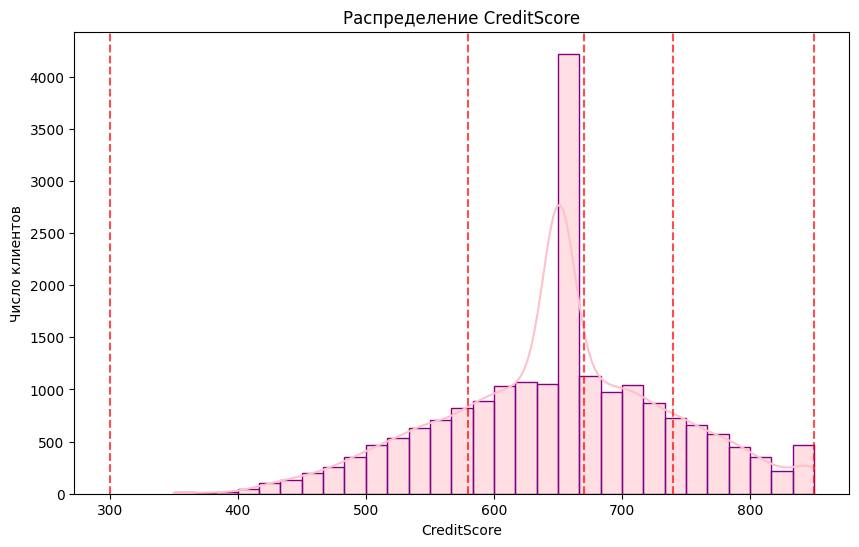

In [125]:
plt.figure(figsize = (10,6))
sns.histplot(df_clean['CreditScore'], bins = 30, kde = True, color = 'pink', edgecolor = 'purple')
plt.title('Распределение CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Число клиентов')
plt.axvline(x = 300, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 580, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 670, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 740, color = 'red', linestyle = '--', alpha = 0.7)
plt.axvline(x = 850, color = 'red', linestyle = '--', alpha = 0.7)
plt.show()

In [126]:
bins_credit = [300, 580, 670, 740, 850]
labels_credit = ['Low', 'Fair', 'Good','Excellent']
df_train['CreditScore_bin'] = pd.cut(df_train['CreditScore'], bins = bins_credit, labels = labels_credit)
df_test['CreditScore_bin'] = pd.cut(df_test['CreditScore'], bins = bins_credit, labels = labels_credit)

In [127]:
#посмотрим размеры выбранных групп:
bins = [300, 580, 670, 740, 850]
labels = ['Low', 'Fair', 'Good','Excellent']
df_clean['CreditScore_bin'] = pd.cut(df_clean['CreditScore'], bins = bins, labels = labels)
df_train['CreditScore_bin'].value_counts().sort_index()

CreditScore_bin
Low          3146
Fair         6497
Good         3000
Excellent    2357
Name: count, dtype: int64

В группе Fair почти половина, остальные группы достаточно большие

## Рассчет WOE/IV

In [128]:
#bins = [18, 25, 35, 45, 56, 100]
#labels = ['18-25', '26-35', '36-45', '46-56', '57+']
#df['Age_bin_custom'] = pd.cut(df['Age'], bins = bins, labels = labels)

In [129]:
features_final = ['Age_bin_custom', 'Balance_bin_custom', 'NumOfProducts', 'Geography', 'IsActiveMember', 'Complain_Yes']

In [130]:
woe_dict = {}
iv_dict = {}

features_for_woe = [
    'Age_bin_custom', 'Balance_bin_custom', 'CreditScore_bin', 'NumOfProducts', 'Geography', 'IsActiveMember', 'Complain_Yes'
]
for feature in features_for_woe:
    woe, iv = calc_woe_iv(df_train, feature, 'Exited')
    woe_dict[feature] = woe['woe'].to_dict()
    iv_dict[feature] = iv
    print(f'{feature}: IV = {iv:.3f}')

#удалила 'Satisfaction_Provided', 'Complain_No','Complain_Missing','Tenure','Gender', 'CreditScore_was_missing', 'Age_was_anomalous'

Age_bin_custom: IV = 0.346
Balance_bin_custom: IV = 0.041
CreditScore_bin: IV = 0.006
NumOfProducts: IV = 0.248
Geography: IV = 0.060
IsActiveMember: IV = 0.052
Complain_Yes: IV = 2.299


/tmp/ipykernel_412451/3803037577.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  woe_df = df.groupby(col)[target].agg(['count', 'sum'])
/tmp/ipykernel_412451/3803037577.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  woe_df = df.groupby(col)[target].agg(['count', 'sum'])
/tmp/ipykernel_412451/3803037577.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  woe_df = df.groupby(col)[target].agg(['count', 'sum'])


Age_bin_custom: IV = 0.346  ---> ✔сильный - очень информативен

Balance_bin_custom: IV = 0.041 ---> ⚪очень слабый - почти неинформативен

CreditScore_bin: IV = 0.006 ---> почти бесполезный - можно исключить

NumOfProducts: IV = 0.248 ---> ✔хороший - важный признак

Geography: IV = 0.060 --->⚪ слабый, но может быть полезным

IsActiveMember: IV = 0.052 ---> ⚪слабый, но может быть полезным 

Complain_Yes: IV = 2.299 ---> ❓аномально высокий, требует внимания

Высокое значение IV = 2.299  обусловлено экстремально сильной связью:

    - после жалобы клиент уходит в 71% случаев

    - без жалобы только в 7%

это не ошибка, а сигнал: обработка жалоб - ключевая проблема оттока.
Признак оставлен без изменений, он отражает реальную бизнес-рискованность

In [131]:
df_train_model = df_train.copy()
df_test_model = df_test.copy()

for feature in woe_dict:
    new_col = f'{feature}_woe'

    #приводим к строке, чтобы избежать проблем с category
    df_train_model[feature] = df_train_model[feature].astype(str)
    df_test_model[feature] = df_test_model[feature].astype(str)
    #заполняем NaN нулем (нейтральное состояние woe)
    df_train_model[new_col] = df_train_model[feature].map(woe_dict[feature]).fillna(0)
    df_test_model[new_col] = df_test_model[feature].map(woe_dict[feature]).fillna(0)

In [132]:
#переcчитаем woe вручную для Сomplain_Yes
group = df_train.groupby('Complain_Yes')['Exited'].agg(['count', 'sum'])
group.columns = ['total', 'churned']
group['non_churned'] = group['total'] - group['churned']

total_non = group['non_churned'].sum()
total_churn = group['churned'].sum()

group['dist_non'] = group['non_churned'] / total_non
group['dist_churn'] = group['churned'] / total_churn

group['woe'] = np.log(group['dist_non'] / group['dist_churn'])
group['iv'] = (group['dist_non'] - group['dist_churn']) * group['woe']
iv = group['iv'].sum()

print(f'реальный {iv:.3f}')

реальный 2.299


In [133]:
#df_train['Complain_Yes'] = (df_train['Complain'] == 1).astype('Int8')
#df_train['Complain_No'] = (df_train['Complain'] == 0).astype('Int8')
#df_train['Complain_Missing'] = df_train['Complain'].isnull().astype('Int8')

#df_test['Complain_Yes'] = (df_test['Complain'] == 1).astype('Int8')
#df_test['Complain_No'] = (df_test['Complain'] == 0).astype('Int8')
#df_test['Complain_Missing'] = df_test['Complain'].isnull().astype('Int8')

In [134]:
#проверка формулы woe
group = df_train.groupby('Complain_Yes')['Exited'].agg(['count', 'sum'])
group['non_churned'] = group['count'] - group['sum']

total_non = group['non_churned'].sum()
total_churn = group['sum'].sum()

group['dist_non'] = group['non_churned'] / total_non
group['dist_churn'] = group['sum'] / total_churn

group['woe'] = np.log(group['dist_non'] / group['dist_churn'])

group['iv'] = (group['dist_non'] - group['dist_churn']) * group['woe']
iv = group['iv'].sum()

print(f'IV = {iv:.3f}')
print(group[['non_churned', 'sum', 'dist_non', 'dist_churn', 'woe']])

IV = 2.299
              non_churned   sum  dist_non  dist_churn       woe
Complain_Yes                                                   
0                   11092   824   0.92634    0.272307  1.224313
1                     882  2202   0.07366    0.727693 -2.290425


<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Хорошо, посчитали WOE для каждого бина и определили IV по признакам в целом.

Замечатльно, что способна составить и реализовать алгоритм для данного способа бинирования признаков, который часто применяется в скоринговых моделях.
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Для реализации оптимального бининга признаков, рекомендую изучить и использовать библиотеку `optbinning` (https://gnpalencia.org/optbinning/). Упрощает бинаризацию и позволяет встраивать бининг в пайплан обучения модели.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Попробовала данную библиотеку для признаков Age и Balance, можете посмотреть подробнее в разделах 'биннинг возраста' и 'биннинг баланса' создала подраздлелы, в которых выбираю оптимальный биннинг под ситуацию.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

Хорошо, что попробовала библиотеку `optbinning` и сравнила результаты. Использовать ее или нет, решать тебе как аналитику. Знаю, что многие банки успешно используют данную библиотеку, т.к. она позволяет значительно ускорить процесс обработки признаков. При желании, все парамметры бинирования настраиваются для каждого признака, а пропуски и не знакомые значения помещаются в отдельные категории. Плюсом есть возможность построения скоринговой карты, что важно для интерпретации результатов.

Отключить ворнинги, которые возникают при использованиии данной библиотеки можно с помощью кода:
```python
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила.</div>

# Подготовка и обучение модели логистической регрессии

In [135]:
#cписок признаков для модели
#features_final = ['Age_bin_custom', 'Balance_bin_custom', 'NumOfProducts', 'Geography', 'IsActiveMember', 'Complain_Yes', 'Risk_Profile_1']
selected_cols = [f'{feat}_woe' for feat in features_final]

In [136]:
# применим woe к train и  test
df_train_model = df_train.copy()
df_test_model = df_test.copy()

for feature in woe_dict:
    new_col = f'{feature}_woe'

    #df_train_model[feature] = df_train_model[feature].astype(str)
    #df_test_model[feature] = df_test_model[feature].astype(str)
    
    df_train_model[new_col] = df_train_model[feature].map(woe_dict[feature])
    df_test_model[new_col] = df_test_model[feature].map(woe_dict[feature])

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Дублирование кода? Мы данную операцию уже выполнили несколько ячеек выше.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Действительно, удалила лишние строки кода.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

In [137]:
#подгогтовим Х и У
selected_cils = [f'{feat}_woe' for feat in features_final]

X_train = df_train_model[selected_cols]
X_test = df_test_model[selected_cols]
y_train = df_train_model['Exited']
y_test = df_test_model['Exited']

In [138]:
X_train.isnull().sum()

Age_bin_custom_woe        0
Balance_bin_custom_woe    0
NumOfProducts_woe         0
Geography_woe             0
IsActiveMember_woe        0
Complain_Yes_woe          0
dtype: int64

In [139]:
#обучим логистическую регрессию
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

#прогноз вероятности
y_pred_proba = model.predict_proba(X_test)[:,1]

#AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC: {auc:.3f}')

AUC-ROC: 0.849


Получилась высокая способность модели

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Метрика на хорошем уровне.
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

1. Если имеется дисбаланс классов целевого признака, а это наш случай, то при создании модели желательно указывать параметр `class_weight`.

1. Для повторяемости результатов, рекомендуется у модели фиксировать параметр `random_state`.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

In [140]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': selected_cols,
    'Coeffitient': model.coef_[0]
}).round(3)

print('Коэффициенты модели:')
print(coefficients)

Коэффициенты модели:
                  Feature  Coeffitient
0      Age_bin_custom_woe       -0.588
1  Balance_bin_custom_woe       -0.209
2       NumOfProducts_woe       -0.565
3           Geography_woe       -0.326
4      IsActiveMember_woe       -0.329
5        Complain_Yes_woe       -0.929


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Заголовок таблици и формат данных в ячейках можно задавать через стиль:
```python
coefficients = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Coeffitient': model.coef_[0]
})
coefficients.style.format(precision=3).set_caption('Коэффициенты модели:')
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Интересно, буду знать, изменила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Отрицательный woe - высокий риск ухода, модель "говорит": чем ниже это число (woe), тем выше шанс ухода и ставит отрицательный коэффициент

-----------------------------------------------------------------------------------------
Например, 

    - Клиент 1, жаловался,

    Complain_Yes_woe = -2.29

    -0.93 * -2.29 = + 2.13 ---> увеличивает вероятность ухода 


    - Клиент 2, не жаловался

    Complain_Yes_woe = 1.22

    -0.93 * 1.22 = -1.14 ---> уменьшает вероятность ухода 
----------------------------

Отрицательный коэффициент + отрицательный woe = + = риск ухода растет

In [141]:
#
y_pred = model.predict_proba(X_test)[:,1]

risk_groups = pd.cut(y_pred_proba,
                    bins = [0, 0.3, 0.6, 1],
                    labels = ['Низкий', 'Средний', 'Высокий'])

risk_groups.value_counts()

Низкий     3995
Средний     147
Высокий     858
Name: count, dtype: int64

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

На основе чего выбраны границы для категорий 'Низкий', 'Средний', 'Высокий'?
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Прокомментировала в файле.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Большинство клиентов лояльны, 858 клиентов срочно надо удерживать, клиентов со средним риском немного

In [142]:
#простая кросс-валидация
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(model, X_train, y_train, cv = 5, scoring = 'roc_auc')
print(f'CV AUC : {cv_auc.mean():.3f} +- {cv_auc.std():.3f}')

CV AUC : 0.854 +- 0.003


Средний AUC по 5 фолдам 0.854, почти совпадает с AUC test(0.849), значит модель не переобучилась,

+-0.003 - очень маленькое стандартное отклонение ---> модель стабильна на разных частях данных, результат не случаен, она действительно понимает закономерности

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Все верно.
</div>

In [143]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_pred_lr = calibrated_lr.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, t = precision_recall_curve(y_test, y_pred_lr)
auc_pr_lr = auc(recall_lr, precision_lr)

#график
plt.figure(figsize = (8, 6))
plt.plot(recall_lr, precision_lr, label = f'Logistic Regression (AUC-PR = {auc_pr_lr:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая: Logistic Regression')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

NameError: name 'calibrated_lr' is not defined

<div class="alert alert-block alert-danger">
<h2> Комментарий Александра 🤔<a class="tocSkip"></h2>

Ошибка в коде: не определена переменная `calibrated_lr`.

Нужно исправить.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Действительно, исправила.</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий Александра (2) 🤔<a class="tocSkip"></h2>

Опять аналогичная ошибка в коде: не определена переменная `final_lr_model`. Смотри в `With_anomalous_v2.ipynb`, ячейка `148`.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Исправила, код перезапустила и вроде как, ошибки нет)) .</div>

AUC-PR = 0.719, PR-кривая показывает, что модель отлично работает при низком и среднем recall, а при высоком recall - точность падает, что является нормой

In [144]:
#прогноз классов(по порогу 0.5)

#вероятности
y_pred_proba = model.predict_proba(X_test)[:, 1]

#бинарные предсказания: если вероятностью > 0.5 --> уйдет
y_pred = (y_pred_proba > 0.5).astype(int)

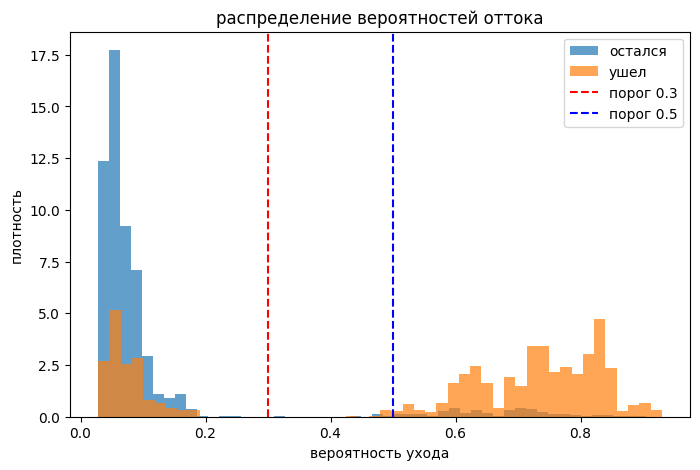

In [145]:
plt.figure(figsize = (8,5))
plt.hist(y_pred_proba[y_test == 0], bins = 50, alpha = 0.7, label = 'остался', density = True)
plt.hist(y_pred_proba[y_test == 1], bins = 50, alpha = 0.7, label = 'ушел', density = True)
plt.axvline(x = 0.3, color = 'red', linestyle = '--', label = 'порог 0.3')
plt.axvline(x = 0.5, color = 'blue', linestyle = '--', label = 'порог 0.5')
plt.title('распределение вероятностей оттока')
plt.xlabel('вероятность ухода')
plt.ylabel('плотность')
plt.legend()
plt.show()

In [146]:
example_complained = df_test_model[df_test['Complain_Yes'] == 1]['Complain_Yes_woe']
example_not = df_test_model[df_test['Complain_Yes'] == 0]['Complain_Yes_woe']

print(example_complained.values[:5])
print(example_not.values[:5])

[-2.29042528 -2.29042528 -2.29042528 -2.29042528 -2.29042528]
[1.22431286 1.22431286 1.22431286 1.22431286 1.22431286]


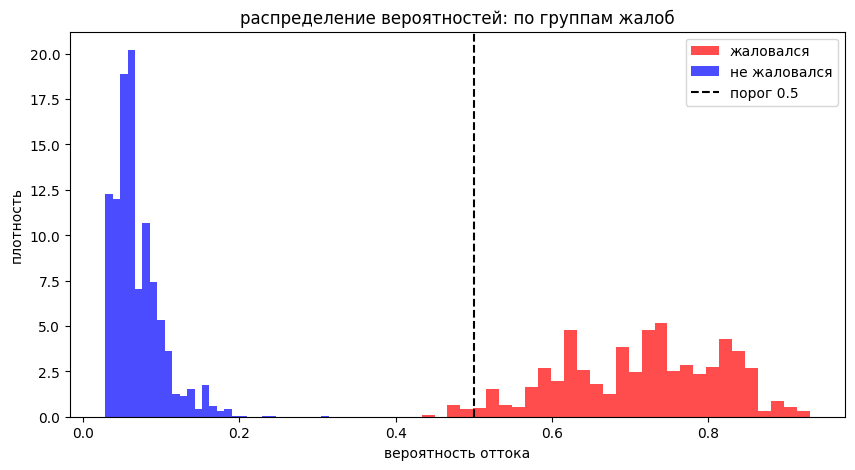

In [147]:
mask_complained = df_test['Complain_Yes'] == 1
mask_not = df_test['Complain_Yes'] == 0

plt.figure(figsize = (10,5))

plt.hist(y_pred_proba[mask_complained], bins = 30, alpha = 0.7, label = 'жаловался', density = True, color = 'red')

plt.hist(y_pred_proba[mask_not], bins = 30, alpha = 0.7, label = 'не жаловался', density = True, color = 'blue')

plt.axvline(x = 0.5, color = 'black', linestyle = '--', label = 'порог 0.5')
plt.title('распределение вероятностей: по группам жалоб')
plt.xlabel('вероятность оттока')
plt.ylabel('плотность')
plt.legend()
plt.show()

модель четко разделяет самых рискованных клиентов, видит что жалоба - главный триггер и реагирует адекватно

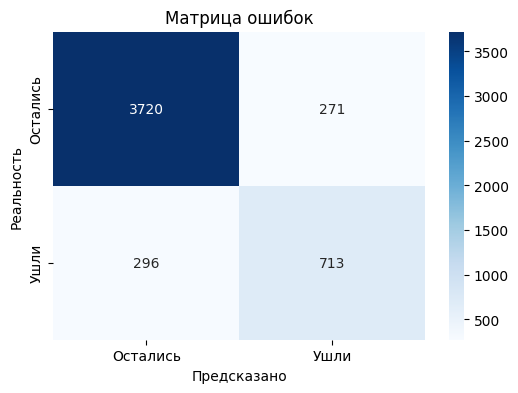

In [148]:
#Матрица ошибок
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#матрица
cm = confusion_matrix(y_test, y_pred)

#визуализация
plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', 
           xticklabels = ['Остались', 'Ушли'],
           yticklabels = ['Остались', 'Ушли'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

In [149]:
print(classification_report(y_test, y_pred, target_names = ['Остался', 'Ушел']))

              precision    recall  f1-score   support

     Остался       0.93      0.93      0.93      3991
        Ушел       0.72      0.71      0.72      1009

    accuracy                           0.89      5000
   macro avg       0.83      0.82      0.82      5000
weighted avg       0.89      0.89      0.89      5000



precision для класса 'ушел' = 0.72:

    из тех, кого модель пометила как рискованных, 72% действительно ушли. 

recall для класса 'ушел' = 0.71:
    
        модель нашла только 71% всех ушедших клиентов

Я проверила возможность повышения recall за счет:

     - снижения порога принятия решения

     - добавления бизнес-правил

Но такие меры не привели к росту recall, потому что модель уже сама распознает этих клиентов из-за высокой информативности признаков (к примеру, Complain_Yes)

Дальнейшее увеличение recall потребовало бы значительного роста ложных срабатываний(снижение precision), а мы не знаем стоимость 'срабатывания', возможно удержание клиентов, которые итак не собирались уходить выйдет дороже, чем упустить пару-тройку клиентов

Учитывая баланс между полнотой и точностью, а также стабильность модели(AUC = 0.85), оставляю текущую версию как оптимальную

Найдем гиперпараметры

In [150]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear'],
    'max_iter': [1000],
    'class_weight': ['balanced']
}

log_reg = LogisticRegression(random_state = 42)

grid_search_lr = GridSearchCV(
    estimator = log_reg,
    param_grid = param_grid,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

grid_search_lr.fit(X_train, y_train)

print('лучшие параметры: ', grid_search_lr.best_params_)
print('лучший auc: ', grid_search_lr.best_score_.round(3))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
лучшие параметры:  {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
лучший auc:  0.854


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Если ячека может выполняеться долго, а подбор гиперпарметров одна из таких операций, то желательно в начале ячейки ставить `%%time`.

Это позволит, тому кто будет смотреть данный блокнот, оценить время выполнения ячейки и не запускать ее в случае, если время будет слишком длительным.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

In [151]:
#создаем модель с лучшими параметрами
final_lr_model = LogisticRegression(
    C = 0.01,
    class_weight = 'balanced',
    max_iter = 1000,
    penalty = 'l2',
    solver = 'liblinear',
    random_state = 42
)

#обучаем на поллных train
final_lr_model.fit(X_train, y_train)

#предсказываем на test
y_pred_proba_lr_final = final_lr_model.predict_proba(X_test)[:,1]
y_pred_lr_final = (y_pred_proba_lr_final > 0.5).astype(int)

#оценка
from sklearn.metrics import roc_auc_score, classification_report

print('final LR AUC:', roc_auc_score(y_test, y_pred_proba_lr_final))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_final))

final LR AUC: 0.849113056408634

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3991
           1       0.72      0.71      0.72      1009

    accuracy                           0.89      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.89      0.89      0.89      5000



In [152]:
#простая кросс-валидация
from sklearn.model_selection import cross_val_score

cv_auc_ = cross_val_score(final_lr_model, X_train, y_train, cv = 5, scoring = 'roc_auc')
print(f'CV AUC : {cv_auc_.mean():.3f} +- {cv_auc_.std():.3f}')

CV AUC : 0.854 +- 0.002


После обучения с учетом гиперпараметров показания кросс-валидации улучшились

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

OK. Мы получили обученную модель, достаточно не плохого качества.
</div>

In [153]:
#Посмотрим новый признак: возрастные с высоким балансом

In [154]:
#df_train['Old_high_balance'] = (
#    (df_train['Age'] >= 50) &
#    (df_train['Balance'] > 150000) 
#).astype(int)

#df_test['Old_high_balance'] = (
#    (df_test['Age'] >= 50) &
#    (df_test['Balance'] > 150000) 
#).astype(int)

#print('количество Old_high_balance в train')
#print(df_train['Old_high_balance'].sum())
#print('количество Old_high_balance в test')
#print(df_test['Old_high_balance'].sum())

In [155]:
#Old_high_balance_mask = df_test['Old_high_balance'] == 1

#print('отток среди Old_high_balance')
#print(df_test[Old_high_balance_mask]['Exited'].mean().round(3))

#print('отток среди остальных')
#print(df_test[~Old_high_balance_mask]['Exited'].mean().round(3))

In [156]:
#df_train['Risk_Profile_1'] = (
    #(df_train['Age'] >= 40) & (df_train['Age'] <= 50) &
#    (df_train['NumOfProducts'] >= 3) &
 #   (df_train['Geography'] == 'Germany') 
    #(df_train['IsActiveMember'] == 0)  
    #(df_train['Complain_Yes'] == 1) &
    #(df_train['Balance'] > 150000) 
#).astype(int)

#df_test['Risk_Profile_1'] = (
    #(df_test['Age'] >= 40) & (df_train['Age'] <= 50) &
#    (df_test['NumOfProducts'] >= 3) &
  #  (df_test['Geography'] == 'Germany') 
    #(df_test['IsActiveMember'] == 0)  
    #(df_test['Complain_Yes'] == 1) &
    #(df_test['Balance'] > 150000) 
#).astype(int)

#print('количество Risk_Profile_1 в train')
#print(df_train['Risk_Profile_1'].sum())
#print('количество Risk_Profile_1 в test')
#print(df_test['Risk_Profile_1'].sum())

In [157]:
#провести тест с этим правилом
#final_risk = (y_pred_proba > 0.5) | \ 
#        ((df_test['Complain_Yes'] == 1) & (df_test['IsActiveMember'] == 0))

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Весь не рабочий код из финального отчета убираем!
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Удалила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

# Подготовка и обучение модели случайный лес

In [158]:
features_final_rf = ['Age', 'Balance', 'NumOfProducts', 'Complain_Yes', 'CreditScore']
#удалила: 'Geography', 'Gender', 'IsActiveMember'

In [159]:
X_train_rf = df_train[features_final_rf].copy()
X_test_rf = df_test[features_final_rf].copy()
y_train_rf = df_train['Exited'].copy()
y_test_rf = df_test['Exited'].copy()

Случайный лес чувствителен к лишним признакам, посмотрим какие признаки важны для модели и включим их в выборку

In [160]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_rf, y_train_rf)

importances = model.feature_importances_
feature_names = X_train_rf.columns

import pandas as pd
feat_importances = pd.Series(importances, index = feature_names).sort_values(ascending = False)
print(feat_importances)

Complain_Yes     0.398959
Balance          0.261330
CreditScore      0.180232
Age              0.131798
NumOfProducts    0.027681
dtype: float64


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

1. При дисбалансе классов целевого признака, указываем `class_weight='balanced'`.

1. Для повторяемости результатов, фиксируем `random_state`.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

In [161]:
X_train_rf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 67 to 7159
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            15000 non-null  float64
 1   Balance        15000 non-null  float64
 2   NumOfProducts  15000 non-null  int64  
 3   Complain_Yes   15000 non-null  int64  
 4   CreditScore    15000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 703.1 KB


типы числовые

In [162]:
#проверим на пропуски
if X_train_rf.isnull().sum().sum() > 0:
    print('есть NaN в X_train_rf - заполняем')
    X_train_rf = X_train_rf.fillna(-1)
if X_test_rf.isnull().sum().sum() > 0:
    print('есть NaN в X_test_rf - заполняем')
    X_test_rf = X_test_rf.fillna(-1)

In [163]:
#обучим случайный лес
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

#модель
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 8,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42,
    n_jobs = -1
)

#обучение
rf_model.fit(X_train_rf, y_train)

#прогноз вероятности
y_pred_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

#AUC
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f'AUC-ROC (Random Forest): {auc_rf:.3f}')

AUC-ROC (Random Forest): 0.894


Случайный лес выдал больший AUC, чем логистическая регрессия

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Метрика на хорошем уровне.
</div>


Важность признаков:
         Feature  Importance
3   Complain_Yes    0.757987
0            Age    0.086564
1        Balance    0.070743
4    CreditScore    0.050561
2  NumOfProducts    0.034145


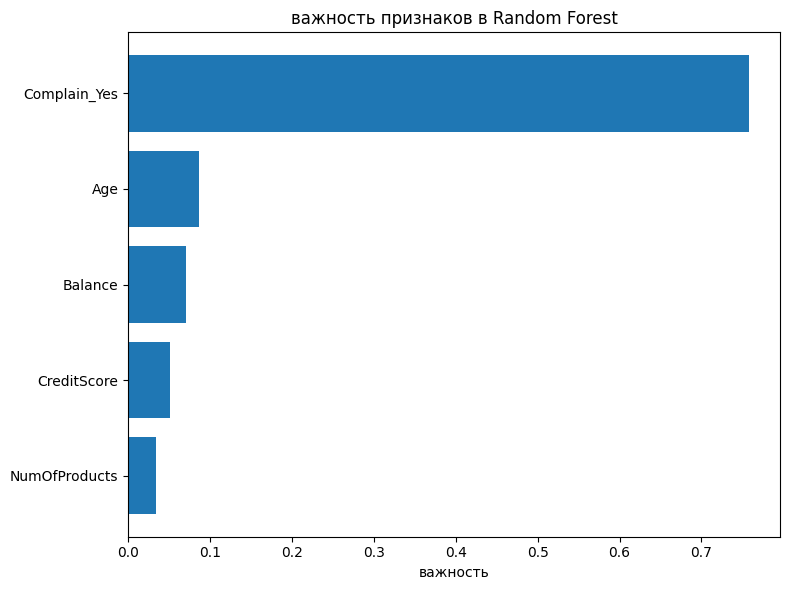

In [164]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending = False)

print('\nВажность признаков:')
print(feat_importance)

#график
plt.figure(figsize = (8, 6))
top10 = feat_importance.head(10)
plt.barh(top10['Feature'], top10['Importance'])
plt.title('важность признаков в Random Forest')
plt.xlabel('важность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Диаграмму важности признаков можно построить прямо в таблице, с помощью стилей и метода `bar()`:
```python
feat_importance.style.bar()
```
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила, интересно выглядит, не знала о таком способе вывода графика.</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий Александра (2) 🤔<a class="tocSkip"></h2>

Ошибка в коде: не определена переменная `feat_importance`. Смотри в `With_anomalous_v2.ipynb`, ячейка `164`.

И конструкция `.style.bar()` работает только для датафрейма, но не для серии.
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра (2) 🤓<a class="tocSkip"> </h2>

Рекомендую после всех правок, перезапускать ядро и выполнять все ячейки блокнота, чтоб выловить все косячки. Кнопка на панели с двумя стрелками &#9193;.  

Блокнот должен полностью исполняться без ошибок.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Исправила.</div>

признак Complain_Yes оказывает очень большое влияние на модель

Посмотрим кросс-валидацию до подбора гиперпараметров

In [165]:
rf_base = RandomForestClassifier(random_state = 42)
cv_scores_base = cross_val_score(rf_base, X_train_rf, y_train_rf, cv = 5, scoring = 'roc_auc')

print(f'базовая модель: {cv_scores_base.mean():.3f} +- {cv_scores_base.std():.3f}')

базовая модель: 0.868 +- 0.003


<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>

Алгоритм случайного леса более ресурсоемкий по сравнению с логистической регрессий, обучается дольше, поэтому ставим `%%time` в начало ячейки.
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> Добавила.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

Средний AUC = 0.868 близок к AUC = 0.894, разброс 0.003 очень маленький, следовательно, модель не переобучается

In [166]:
#бинарный прогноз 
y_pred_rf = (y_pred_proba_rf > 0.2).astype(int)

print('\n Classification Report(RF)')
print(classification_report(y_test_rf, y_pred_rf))


 Classification Report(RF)
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3991
           1       0.71      0.72      0.71      1009

    accuracy                           0.88      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.88      0.88      0.88      5000



Precision для 'ушел': из 100 помеченных как рискованные 71 действительно уйдут

Recall для 'ушел': модель нашла 72% всех ушедших


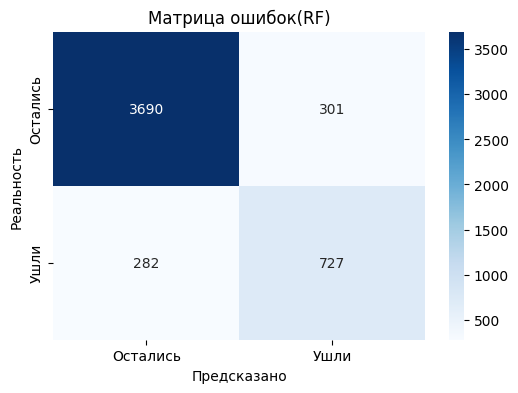

In [167]:
#Матрица ошибок
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#матрица
cm = confusion_matrix(y_test_rf, y_pred_rf)

#визуализация
plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', 
           xticklabels = ['Остались', 'Ушли'],
           yticklabels = ['Остались', 'Ушли'])
plt.title('Матрица ошибок(RF)')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

Найдем гиперпараметры

In [168]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [8, 10, 12], 
    'min_samples_split': [10,20],
    'min_samples_leaf': [5,10],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state = 42, n_jobs = -1)

grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

grid_search.fit(X_train_rf, y_train_rf)

print('лучшие параметры: ', grid_search.best_params_)
print('лучший auc: ', grid_search.best_score_.round(3))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
лучшие параметры:  {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
лучший auc:  0.891


'class_weight': 'balanced' - учитывает дисбаланс классов

'max_depth': 8 - ограничивает глубину деревьев для снижения переобчения

'min_samples_leaf': 5 - минимум 5 клиентов в листе для стабильности

'min_samples_split': 10 - не делим узлы с <10 клиентов

'n_estimators': 200 - достаточно деревьев для точности

In [169]:
y_pred_tuned = (y_pred_proba_rf > 0.2).astype(int)

print(classification_report(y_test_rf, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3991
           1       0.71      0.72      0.71      1009

    accuracy                           0.88      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.88      0.88      0.88      5000



Нашли гиперпараметры, теперь обучим финальную модель с этими параметрами на полных данных train

In [170]:
#создаем модель с лучшими параметрами
final_rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    max_depth = 8,
    min_samples_leaf = 5,
    min_samples_split = 10, 
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)

#обучаем на поллных train
final_rf_model.fit(X_train_rf, y_train_rf)

#предсказываем на test
y_pred_proba_final = final_rf_model.predict_proba(X_test_rf)[:,1]
y_pred_final = (y_pred_proba_final > 0.5).astype(int)

#оценка
from sklearn.metrics import roc_auc_score, classification_report

print('final RF AUC:', roc_auc_score(y_test_rf, y_pred_proba_final))
print('\nClassification Report:')
print(classification_report(y_test_rf, y_pred_final))

final RF AUC: 0.8925832627872575

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3991
           1       0.72      0.71      0.72      1009

    accuracy                           0.89      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.89      0.89      0.89      5000



AUC стал немного ниже: был 0.894, стал 0.893

Посмотрим кросс-валидацию после обучения модели с учетом гиперпараметров

In [171]:
cv_scores_tuned = cross_val_score(final_rf_model, X_train_rf, y_train_rf, cv = 5, scoring = 'roc_auc')
print(f'улучшенная модель: {cv_scores_tuned.mean():.3f} +- {cv_scores_tuned.std():.3f}')

улучшенная модель: 0.892 +- 0.004


Кросс-валидация после подбора гиперпараметровм показывает лучшие результаты, 
Усредненный auc по пяти фолдам стал лучше на 0.03, разброс стал поменьше, был 0.009, стал 0.004. По данным значениям(0.892 +- 0.004) видно, что модель не переобучается.

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

OK. Финальная модель случайного леса получена.
</div>

# Калибровка случайногог леса(RF) и логистической регрессии(LR)

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

В задании данного пункта не было, но очень интересно.
</div>

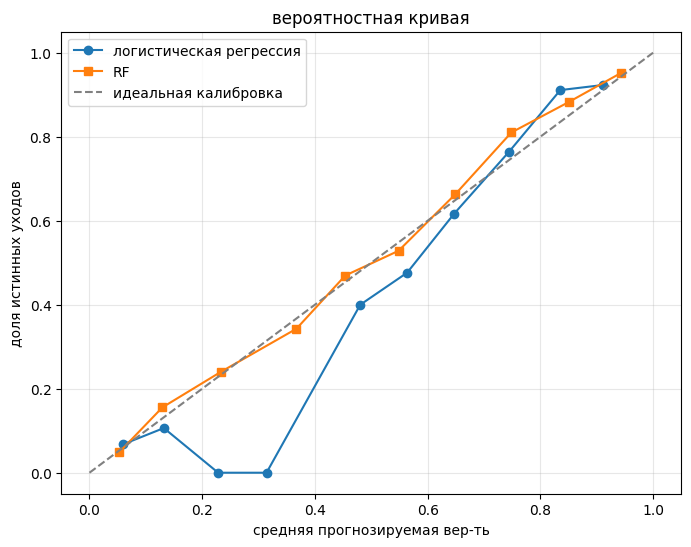

In [172]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

#ДЛЯ ЛОГ РЕГ
prob_true_lr, prob_pred_lr = calibration_curve(
    y_test, y_pred_proba, n_bins = 10
)

#для RF
prob_true_rf, prob_pred_rf = calibration_curve(
    y_test, y_pred_proba_rf, n_bins = 10
)

plt.figure(figsize = (8,6))
plt.plot(prob_pred_lr, prob_true_lr, marker = 'o', label = 'логистическая регрессия')
plt.plot(prob_pred_rf, prob_true_rf, marker = 's', label = 'RF')
plt.plot([0,1], [0,1], linestyle = '--', color = 'gray', label = 'идеальная калибровка')
plt.xlabel('средняя прогнозируемая вер-ть')
plt.ylabel('доля истинных уходов')
plt.title('вероятностная кривая')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

Кривые моделей немного отклоняются от идеальной калиброки, попробуем откалибровать их.

Для начала используем калибровку Isotonic

In [173]:
from sklearn.calibration import CalibratedClassifierCV

#калибруем логистическую регрессию
calibrated_lr = CalibratedClassifierCV(final_lr_model, method = 'isotonic', cv = 3)
calibrated_lr.fit(X_train, y_train)

#калибруем RF
calibrated_rf = CalibratedClassifierCV(final_rf_model, method = 'isotonic', cv = 3)
calibrated_rf.fit(X_train_rf, y_train_rf)

,estimator,RandomForestC...ndom_state=42)
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0


Построим откалиброванные вероятностные кривые

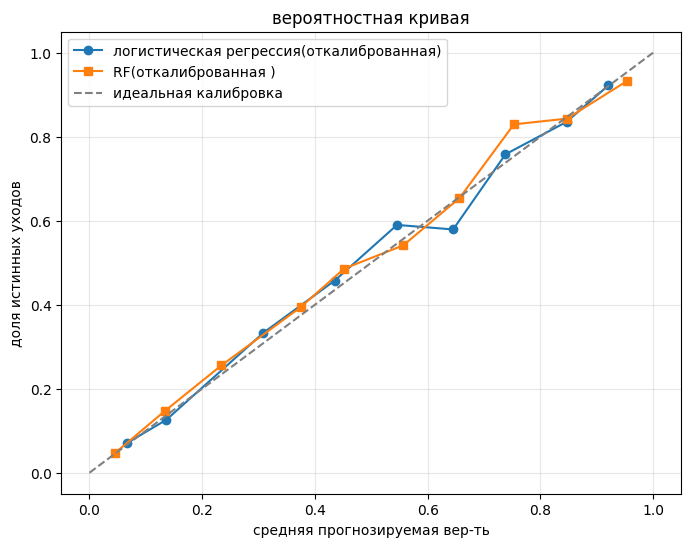

In [174]:
#прогнозы после калибровки
y_proba_cal_lr = calibrated_lr.predict_proba(X_test)[:, 1]
y_proba_cal_rf = calibrated_rf.predict_proba(X_test_rf)[:, 1]

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

#ДЛЯ ЛОГ РЕГ
prob_true_lr, prob_pred_lr = calibration_curve(
    y_test, y_proba_cal_lr, n_bins = 10
)

#для RF
prob_true_rf, prob_pred_rf = calibration_curve(
    y_test, y_proba_cal_rf, n_bins = 10
)

plt.figure(figsize = (8,6))
plt.plot(prob_pred_lr, prob_true_lr, marker = 'o', label = 'логистическая регрессия(откалиброванная)')
plt.plot(prob_pred_rf, prob_true_rf, marker = 's', label = 'RF(откалиброванная )')
plt.plot([0,1], [0,1], linestyle = '--', color = 'gray', label = 'идеальная калибровка')
plt.xlabel('средняя прогнозируемая вер-ть')
plt.ylabel('доля истинных уходов')
plt.title('вероятностная кривая')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

После кабибровки Isotonic логистическая регрессия почти приблизилась к идеалу, хороший результат, рандом форест тоже стал лучше, но в одной-двух точках результат стал хуже(дальше от прямой)(в этом диапазоне модель недооценивает риск, реально уходит больше, чем модель предсказала), попробуем провести еще одну калибровку: Platt Scaling(sigmoid)

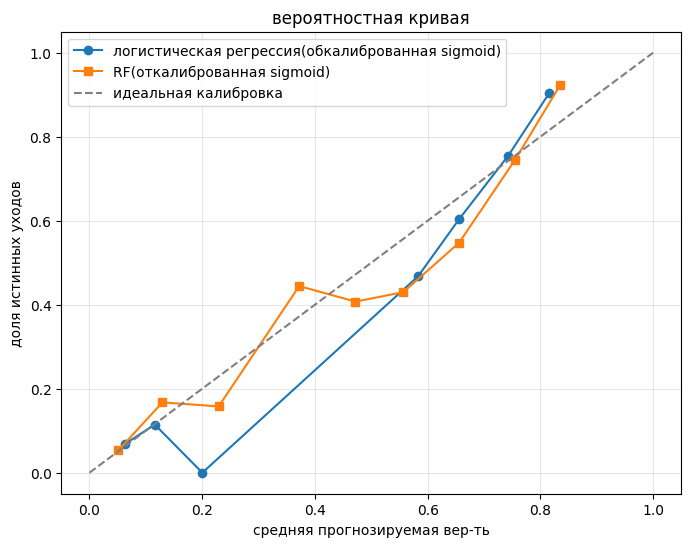

In [175]:
#калибруем через Platt Scaling

#для RF
calibrated_rf_platt = CalibratedClassifierCV(final_rf_model, method = 'sigmoid', cv = 3)
calibrated_rf_platt.fit(X_train_rf, y_train_rf)

#для LR
calibrated_lr_platt = CalibratedClassifierCV(final_lr_model, method = 'sigmoid', cv = 3)
calibrated_lr_platt.fit(X_train, y_train)

#прогноз RF
y_proba_rf_platt = calibrated_rf_platt.predict_proba(X_test_rf)[:, 1]

#прогноз LR
y_proba_lr_platt = calibrated_lr_platt.predict_proba(X_test)[:, 1]

#калибровочная кривая RF
prob_true_platt_rf, prob_pred_platt_rf = calibration_curve(y_test_rf, y_proba_rf_platt, n_bins = 10)

#калибровочная кривая LR
prob_true_platt_lr, prob_pred_platt_lr = calibration_curve(y_test, y_proba_lr_platt, n_bins = 10)

#график
plt.figure(figsize = (8,6))
plt.plot(prob_pred_platt_lr, prob_true_platt_lr, marker = 'o', label = 'логистическая регрессия(обкалиброванная sigmoid)')
plt.plot(prob_pred_platt_rf, prob_true_platt_rf, marker = 's', label = 'RF(откалиброванная sigmoid)')
plt.plot([0,1], [0,1], linestyle = '--', color = 'gray', label = 'идеальная калибровка')
plt.xlabel('средняя прогнозируемая вер-ть')
plt.ylabel('доля истинных уходов')
plt.title('вероятностная кривая')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

Калибровка кривых с помощью sigmoid показывает худший результат, Isotonic дал лучшее значение

Проверим метрику Brier Score, чтобы численно убедиться в корректности калибровки

In [176]:
from sklearn.metrics import brier_score_loss
#получаем вероятности до и после калибровки
probs_uncalibrated = final_rf_model.predict_proba(X_test_rf)[:, 1]
probs_sigmoid = calibrated_rf_platt.predict_proba(X_test_rf)[:, 1]
probs_isotonic = calibrated_rf.predict_proba(X_test_rf)[:, 1]
#считаем Brier Score
brier_uncal = brier_score_loss(y_test_rf, probs_uncalibrated)
brier_sig = brier_score_loss(y_test_rf, probs_sigmoid)
brier_iso = brier_score_loss(y_test_rf, probs_isotonic)

print(f'Uncalibrated: {brier_uncal:.4f}')
print(f'Sigmoid: {brier_sig:.4f}')
print(f'Isotonic: {brier_iso:.4f}')

Uncalibrated: 0.1072
Sigmoid: 0.0868
Isotonic: 0.0853


In [177]:
from sklearn.metrics import brier_score_loss
#получаем вероятности до и после калибровки
probs_uncalibrated = final_lr_model.predict_proba(X_test)[:, 1]
probs_sigmoid = calibrated_lr_platt.predict_proba(X_test)[:, 1]
probs_isotonic = calibrated_lr.predict_proba(X_test)[:, 1]
#считаем Brier Score
brier_uncal = brier_score_loss(y_test, probs_uncalibrated)
brier_sig = brier_score_loss(y_test, probs_sigmoid)
brier_iso = brier_score_loss(y_test, probs_isotonic)

print(f'Uncalibrated: {brier_uncal:.4f}')
print(f'Sigmoid: {brier_sig:.4f}')
print(f'Isotonic: {brier_iso:.4f}')

Uncalibrated: 0.1192
Sigmoid: 0.0910
Isotonic: 0.0895


Так как Brier Score - средняя квадратическая ошибка между предсказанной вероятностью и реальным классом, то чем меньше число, тем ближе предсказанная вероятность к реальному классу.

Следовательно, калибровка Isotonic дает лучшее значение для обеих моделей.

Для RF протестировали два метода калибровки: Isotonic, Platt Scaling(sigmoid)

Isotonic показала лучшую точность, но с небольшим провалом. Platt  смещает вероятности.

Для задачи прогноза оттка рекомендуется использовать Isotonic, так как она дает более точные вероятности

Для обеих моделей выбираем калибровку Isotonic. Сохраним их

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Плюс, за инициативу!
</div>

<div class="alert alert-warning">
<h2> Комментарий Александра 🤓<a class="tocSkip"> </h2>
Появились два вопроса:
    
1. Не совсем понятно чем отличается `Brier Score` от `MSE`.

1. Оказывает ли влияние калибровка модели на метрику, в нашем случае `AUC ROC`?
</div>

<div class="alert alert-info"> <b>Комментарий Ирины:</b> 

1. Не совсем поняла вопрос, Brier Score - это MSE для задачи классификации. Это одно и то же, просто в разных задачах.
    
2. Нет, калибровка не влияет на AUC-ROC, калибровка меняет величину вероятностей. В данном случае я проводила калибровку, чтобы улучшить точность вероятностей.</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

OK
</div>

# Сохранение

In [178]:
#для RF

#выберем лучшую калибровку
best_calibrated_rf = calibrated_rf

#сохраняем
import joblib
joblib.dump(best_calibrated_rf, 'best_calibrated_rf.pkl')
#используем
best_calibrated_rf = joblib.load('best_calibrated_rf.pkl')

#прогноз
y_pred_proba = best_calibrated_rf.predict_proba(X_test_rf)[:, 1]

######


In [179]:
#для LR
#выберем лучшую калибровку
best_calibrated_lr = calibrated_lr

#сохраняем
import joblib
joblib.dump(best_calibrated_lr, 'best_calibrated_lr.pkl')
#используем
best_calibrated_lr = joblib.load('best_calibrated_lr.pkl')

#прогноз
y_pred_proba = best_calibrated_lr.predict_proba(X_test)[:, 1]

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

ОК! Сможем поделиться модельками с коллегами.
</div>

# Финальный отчет 

1) Цель проекта - провести анализ данных оттока клиентов, построить модель прогноза оттока клиентов банка и выявить ключевые факторы, влияющие на решение клиента уйти.

2) Методология

   - Предобработка и EDA
   - Биннинг числовых признаков
   - Преобразовывание категорий через WOE/IV для логистической регрессии
   - Моделирование: обучение логистической регрессии и Random Forest с калибровкой и на гиперпараметрах
   - Оценка качества: AUC, Precision, Recall, матрица ошибок, кросс валидация
     
3)

   * Ключевые результаты Логистической регрессии

   Качество модели(с учетом гиперпараметров):

   
       - AUC-ROC = 0.849 - высокая способность к разделению.

       - CV AUC: 0.854 +- 0.002 - модель стабильна, переобучения нет.

   Метрики:

        Класс     Precision     Recall

       Остался      0.93          0.93

        Ушел        0.72          0.71

   Самые важные признаки(на основании woe/iv):

   1. Сomplain_Yes
   2. Age_bin_custom
   3. NumOfProducts
   4. IsActiveMember
   5. Geography

   * Ключевые результаты Случайного леса

    Качество модели(с учетом гиперпараметров):

   
       - AUC-ROC = 0.893 - высокая способность к разделению.

       - CV AUC: 0.892 +- 0.004 - модель стабильна, переобучения нет.

   Метрики:

        Класс     Precision     Recall

       Остался      0.93          0.93

        Ушел        0.72          0.71

   Самые важные признаки:

   1. Сomplain_Yes
   2. Age
   3. Balance
   4. CreditScore
   5. NumOfProducts


Калибровкеа моделей: обе модели хорошо откалиброваны - вероятности можно использовать в бизнесе.
Random Forest показывает лучшие результаты по метрике AUC-ROC (0.893). Обе модели готовы к внедрению

5) Главный инсайт:

   ❗Наличие жалобы - главный драйвер оттока

   Анализ показал:

   - клиенты, подавшие жалобу, уходят в ~71% случаев - независимо от того, как была решена проблема
   - те, кто не жаловался, уходят в ~7% случаев

     Значит, сам факт жалобы - сигнал глубокого недовольства

6) Рекомендации:

   1. Не допускать ситуаций, приводящих к жалобам ---> анализировать причины жалоб: ошибки, долгие очереди, отказы.
   2. Персональное внимание до жалобы.
   3. Автоматическое удержание после жалобы ---> назначить менеджера, предложить бонус сразу
   4. Работа с группами риска:
       - Неактивные клиенты 46-50 лет.
       - С высоким балансом.
       - 3+ продукта.
    5. Мониторинг Германии - самый высокий отток среди стран

<div class="alert alert-success">
<h2> Комментарий Александра 😊<a class="tocSkip"> </h2>

Ирина, в целом отличная работа, но необходимо исправить недочеты.

Пролистал второй вариант отчета, с исключением выбросов, прочитал выводы, комментировать не стал, все хорошо. Что касается оформления и ворнингов, замечания все те же самые.

Буду ждать исправленные варианты.
</div>

<div class="alert alert-success">
<h2> Комментарий Александра (2) 😊<a class="tocSkip"> </h2>

Ирина, вижу что старалась, проделана работа над ошибками, но есть еще что поправить.
</div>